# Diagnose Correlator Scaling Instability

This CPU notebook diagnoses why the correlation-function exponent is unstable. It uses existing data only and does not run Markov dynamics.

Main questions:
- How sensitive is the fully x-averaged N20 correlator exponent to the fit window?
- How different are perfect-correction and postselected x-averaged correlator fits?
- In raw N16 perfect-correction snapshots, how much of the instability comes from averaging wall, bulk, and non-wall regions together?


In [1]:
from __future__ import annotations

import json
import math
import os
import sys
from pathlib import Path
from typing import Any

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
for candidate in [REPO_ROOT, *REPO_ROOT.parents]:
    if (candidate / 'REPO_POLICY.md').exists() and (candidate / 'colab_charge_fluctuations').exists():
        REPO_ROOT = candidate
        break

CHARGE_ROOT = REPO_ROOT / 'colab_charge_fluctuations'
SMALL_ROOT = REPO_ROOT / 'colab_small_system_testing'
N20_CAMPAIGN_ID = 'N20_selected_nsh1_dwtrunc1_init-default_S100_cycles-2Ny'
N20_RUNS_ROOT = CHARGE_ROOT / 'gpu_data' / 'streaming_covariance_observables' / 'campaigns' / N20_CAMPAIGN_ID / 'runs'
N20_FIT_TABLE = CHARGE_ROOT / 'analysis_outputs' / 'streaming_covariance_scaling_fits' / N20_CAMPAIGN_ID / 'tables' / 'streaming_covariance_scaling_fit_summary.csv'
N16_SNAPSHOT_ROOT = SMALL_ROOT / 'gpu_data' / 'pure_state_covariance_snapshots'
N16_MANIFEST_PATH = N16_SNAPSHOT_ROOT / 'campaign_manifest.json'
OUTPUT_ROOT = CHARGE_ROOT / 'analysis_outputs' / 'correlator_scaling_diagnostics'
TABLE_DIR = OUTPUT_ROOT / 'tables'
FIG_DIR = OUTPUT_ROOT / 'figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

WIDTH = 3.375
DPI = 300
try:
    mpl.rcParams['font.family'] = 'CMU Sans Serif'
except Exception:
    pass
mpl.rcParams.update({
    'figure.dpi': DPI,
    'savefig.dpi': DPI,
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'mathtext.fontset': 'cm',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print(f'[paths] repo={REPO_ROOT}')
print(f'[paths] n20 runs={N20_RUNS_ROOT}')
print(f'[paths] n16 snapshots={N16_SNAPSHOT_ROOT}')
print(f'[paths] output={OUTPUT_ROOT}')


[paths] repo=/home/abhuiyan/class_A_fermionic_adaptive_circuit
[paths] n20 runs=/home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/gpu_data/streaming_covariance_observables/campaigns/N20_selected_nsh1_dwtrunc1_init-default_S100_cycles-2Ny/runs
[paths] n16 snapshots=/home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_small_system_testing/gpu_data/pure_state_covariance_snapshots
[paths] output=/home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/correlator_scaling_diagnostics


In [2]:
R_MIN_VALUES = [1, 2, 3, 4, 5, 6]
R_MAX_FRACTIONS = [
    ('Ny//4', lambda ny: ny // 4),
    ('Ny//3', lambda ny: ny // 3),
    ('Ny//2', lambda ny: ny // 2),
]
MIN_FIT_POINTS = 4
TARGET_EXPONENT = 2.0
N20_NY_VALUES = [30, 40, 50]
N20_PROTOCOLS = ['perfect_correction', 'postselect']
N16_NY_VALUES = [30, 40]
N16_NSHELL_VALUES = [1, 2]
N16_SNAPSHOT_CYCLES = [5, 10, 20, 50]
WALL_RADIUS = 1


def forbid_erroneous(path: Path) -> None:
    if 'erroneous_gpu_stuff' in path.parts:
        raise RuntimeError(f'Forbidden path under erroneous_gpu_stuff: {path}')


def save_dataframe(df: pd.DataFrame, path: Path) -> None:
    forbid_erroneous(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + '.tmp')
    df.to_csv(tmp, index=False)
    tmp.replace(path)


def save_figure(fig: plt.Figure, stem: str, *, save: bool = True) -> None:
    if not save:
        return
    for ext in ('png', 'pdf'):
        path = FIG_DIR / f'{stem}.{ext}'
        forbid_erroneous(path)
        fig.savefig(path, bbox_inches='tight', dpi=DPI)


def linear_fit_many(x: np.ndarray, y: np.ndarray) -> dict[str, np.ndarray]:
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if y.ndim != 2:
        raise ValueError(f'y must have shape (curves, points), got {y.shape}')
    n_curve = y.shape[0]
    slope = np.full(n_curve, np.nan, dtype=np.float64)
    intercept = np.full(n_curve, np.nan, dtype=np.float64)
    stderr = np.full(n_curve, np.nan, dtype=np.float64)
    r2 = np.full(n_curve, np.nan, dtype=np.float64)
    n_points = np.zeros(n_curve, dtype=np.int64)
    for idx in range(n_curve):
        mask = np.isfinite(x) & np.isfinite(y[idx])
        n = int(np.count_nonzero(mask))
        n_points[idx] = n
        if n < 2:
            continue
        xv = x[mask]
        yv = y[idx, mask]
        xc = xv - xv.mean()
        yc = yv - yv.mean()
        sxx = float(np.sum(xc * xc))
        if sxx <= 0:
            continue
        m = float(np.sum(xc * yc) / sxx)
        b = float(yv.mean() - m * xv.mean())
        residual = yv - (m * xv + b)
        sse = float(np.sum(residual * residual))
        sst = float(np.sum(yc * yc))
        slope[idx] = m
        intercept[idx] = b
        r2[idx] = 1.0 - sse / sst if sst > 0 else np.nan
        stderr[idx] = math.sqrt((sse / float(n - 2)) / sxx) if n > 2 else np.nan
    return {'slope': slope, 'intercept': intercept, 'slope_stderr': stderr, 'r2': r2, 'n_points': n_points}


def fit_loglog_curve_grid(values: np.ndarray, ry_values: np.ndarray, ny: int) -> pd.DataFrame:
    if values.ndim != 3:
        raise ValueError(f'expected values shape (samples, cycles, ry), got {values.shape}')
    samples, cycles, _ = values.shape
    flat = values.reshape(samples * cycles, values.shape[-1])
    sample_index = np.repeat(np.arange(samples), cycles)
    cycle_pos = np.tile(np.arange(cycles), samples)
    frames = []
    for r_min in R_MIN_VALUES:
        for rmax_label, rmax_fn in R_MAX_FRACTIONS:
            r_max = int(rmax_fn(ny))
            mask = (ry_values >= int(r_min)) & (ry_values <= r_max)
            if int(np.count_nonzero(mask)) < MIN_FIT_POINTS:
                continue
            x = np.log(ry_values[mask].astype(np.float64))
            selected = flat[:, mask]
            y = np.log(np.where((selected > 0) & np.isfinite(selected), selected, np.nan))
            fit = linear_fit_many(x, y)
            frames.append(pd.DataFrame({
                'sample_index': sample_index,
                'cycle_pos': cycle_pos,
                'r_min': int(r_min),
                'r_max': int(r_max),
                'r_max_label': rmax_label,
                'n_fit_ry': fit['n_points'],
                'correlator_loglog_slope': fit['slope'],
                'correlator_exponent': -fit['slope'],
                'correlator_loglog_intercept': fit['intercept'],
                'correlator_loglog_slope_stderr': fit['slope_stderr'],
                'correlator_loglog_r2': fit['r2'],
            }))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def domain_wall_locations(nx: int) -> tuple[int, int]:
    half = int(nx) // 2
    w = max(1, int(nx) // 4)
    return max(0, half - w), min(int(nx) - 1, half + w)


def x_windows_for_geometry(nx: int, *, radius: int = 1) -> dict[str, np.ndarray]:
    xL, xR = domain_wall_locations(nx)
    xs = np.arange(nx, dtype=np.int64)
    left = xs[(xs >= xL - radius) & (xs <= xL + radius)]
    right = xs[(xs >= xR - radius) & (xs <= xR + radius)]
    both = np.union1d(left, right)
    topo = xs[(xs >= xL) & (xs <= xR)]
    topo_bulk = np.setdiff1d(topo, both)
    nonwall = np.setdiff1d(xs, both)
    windows = {
        'full_x': xs,
        'left_wall_window': left,
        'right_wall_window': right,
        'both_walls': both,
        'topological_bulk': topo_bulk,
        'nonwall_control': nonwall,
    }
    for name, arr in windows.items():
        if arr.size == 0:
            raise RuntimeError(f'x-window {name} is empty for Nx={nx}, walls={(xL, xR)}')
    if np.intersect1d(left, right).size:
        raise RuntimeError(f'left/right wall windows overlap for Nx={nx}, radius={radius}')
    return windows


def mode_index(x: np.ndarray, y: np.ndarray, mu: np.ndarray, nx: int) -> np.ndarray:
    return mu + 2 * x + 2 * nx * y

print('[setup] controls loaded')


[setup] controls loaded


## N20 Existing x-Averaged Correlator Window Sweep


In [3]:
def n20_run_dir(ny: int, protocol: str) -> Path:
    return N20_RUNS_ROOT / f'N20x{int(ny)}_nsh1_init-default_{protocol}'


def load_n20_record(ny: int, protocol: str) -> dict[str, Any]:
    run_dir = n20_run_dir(ny, protocol)
    forbid_erroneous(run_dir)
    corr_path = run_dir / 'xavg_square_correlator_vs_ry.npz'
    entropy_path = run_dir / 'entropy_y0avg_vs_ay.npz'
    summary_path = run_dir / 'run_summary.json'
    for path in [corr_path, entropy_path, summary_path]:
        if not path.exists():
            raise FileNotFoundError(path)
    with np.load(corr_path, allow_pickle=False) as z:
        corr = z['xavg_square_correlator_vs_ry'].astype(np.float64, copy=False)
        ry_values = z['ry_values'].astype(np.int64, copy=False)
        sample_indices = z['sample_indices'].astype(np.int64, copy=False)
        cycle_labels = z['cycle_labels'].astype(np.int64, copy=False)
    with np.load(entropy_path, allow_pickle=False) as z:
        entropy = z['entropy_y0avg_vs_ay'].astype(np.float64, copy=False)
        ay_values = z['ay_values'].astype(np.int64, copy=False)
    summary = json.loads(summary_path.read_text())
    if corr.shape[:2] != (len(sample_indices), len(cycle_labels)):
        raise RuntimeError(f'correlator metadata mismatch for {run_dir}')
    if entropy.shape[:2] != corr.shape[:2]:
        raise RuntimeError(f'entropy/correlator sample-cycle mismatch for {run_dir}')
    return {
        'source': 'N20_streaming_xavg',
        'run_dir': run_dir,
        'protocol': protocol,
        'Nx': 20,
        'Ny': int(ny),
        'nshell': 1,
        'sample_indices': sample_indices,
        'cycle_labels': cycle_labels,
        'corr': corr,
        'ry_values': ry_values,
        'entropy': entropy,
        'ay_values': ay_values,
        'summary': summary,
    }

n20_records = [load_n20_record(ny, protocol) for ny in N20_NY_VALUES for protocol in N20_PROTOCOLS]
manifest_rows = []
for rec in n20_records:
    manifest_rows.append({
        'source': rec['source'],
        'protocol': rec['protocol'],
        'Nx': rec['Nx'],
        'Ny': rec['Ny'],
        'samples': len(rec['sample_indices']),
        'cycles': len(rec['cycle_labels']),
        'corr_shape': tuple(rec['corr'].shape),
        'dw_loc': rec['summary'].get('dw_loc'),
        'run_dir': str(rec['run_dir']),
    })
n20_manifest_df = pd.DataFrame(manifest_rows)
display(n20_manifest_df)

n20_frames = []
for rec in n20_records:
    fit_df = fit_loglog_curve_grid(rec['corr'], rec['ry_values'], rec['Ny'])
    cycle_labels = rec['cycle_labels']
    sample_indices = rec['sample_indices']
    fit_df['cycle_label'] = cycle_labels[fit_df['cycle_pos'].to_numpy()]
    fit_df['sample_index'] = sample_indices[fit_df['sample_index'].to_numpy()]
    fit_df['source'] = rec['source']
    fit_df['protocol'] = rec['protocol']
    fit_df['Nx'] = rec['Nx']
    fit_df['Ny'] = rec['Ny']
    fit_df['nshell'] = rec['nshell']
    fit_df['x_window'] = 'full_x_streamed'
    n20_frames.append(fit_df.drop(columns=['cycle_pos']))

n20_window_sweep = pd.concat(n20_frames, ignore_index=True)
n20_window_sweep['abs_error_from_2'] = np.abs(n20_window_sweep['correlator_exponent'] - TARGET_EXPONENT)
n20_window_sweep_path = TABLE_DIR / 'n20_xavg_window_sweep.csv'
save_dataframe(n20_window_sweep, n20_window_sweep_path)
print(f'[saved] {n20_window_sweep_path} rows={len(n20_window_sweep)}')
display(n20_window_sweep.head())


,source,protocol,Nx,Ny,samples,cycles,corr_shape,dw_loc,run_dir
0,N20_streaming_xavg,perfect_correction,20,30,100,60,"(100, 60, 16)","[5, 15]",/home/abhuiyan/class_A_fermionic_adaptive_circ...
1,N20_streaming_xavg,postselect,20,30,1,60,"(1, 60, 16)","[5, 15]",/home/abhuiyan/class_A_fermionic_adaptive_circ...
2,N20_streaming_xavg,perfect_correction,20,40,100,80,"(100, 80, 21)","[5, 15]",/home/abhuiyan/class_A_fermionic_adaptive_circ...
3,N20_streaming_xavg,postselect,20,40,1,80,"(1, 80, 21)","[5, 15]",/home/abhuiyan/class_A_fermionic_adaptive_circ...
4,N20_streaming_xavg,perfect_correction,20,50,100,100,"(100, 100, 26)","[5, 15]",/home/abhuiyan/class_A_fermionic_adaptive_circ...
5,N20_streaming_xavg,postselect,20,50,1,100,"(1, 100, 26)","[5, 15]",/home/abhuiyan/class_A_fermionic_adaptive_circ...


[saved] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/correlator_scaling_diagnostics/tables/n20_xavg_window_sweep.csv rows=424200


,sample_index,r_min,r_max,r_max_label,n_fit_ry,correlator_loglog_slope,correlator_exponent,correlator_loglog_intercept,correlator_loglog_slope_stderr,correlator_loglog_r2,cycle_label,source,protocol,Nx,Ny,nshell,x_window,abs_error_from_2
0,0,1,7,Ny//4,7,-2.381911,2.381911,-5.531453,0.740704,0.674075,1,N20_streaming_xavg,perfect_correction,20,30,1,full_x_streamed,0.381911
1,0,1,7,Ny//4,7,-2.812335,2.812335,-5.301240,0.727907,0.749089,2,N20_streaming_xavg,perfect_correction,20,30,1,full_x_streamed,0.812335
2,0,1,7,Ny//4,7,-3.255999,3.255999,-4.952354,0.584706,0.861147,3,N20_streaming_xavg,perfect_correction,20,30,1,full_x_streamed,1.255999
3,0,1,7,Ny//4,7,-3.544879,3.544879,-4.681988,0.446405,0.926534,4,N20_streaming_xavg,perfect_correction,20,30,1,full_x_streamed,1.544879
4,0,1,7,Ny//4,7,-3.738096,3.738096,-4.484159,0.348135,0.958435,5,N20_streaming_xavg,perfect_correction,20,30,1,full_x_streamed,1.738096


In [4]:
# Validate that r_min=5, r_max=Ny//2 reproduces the existing default scaling table.
existing = pd.read_csv(N20_FIT_TABLE)
existing = existing[['protocol', 'Ny', 'sample_index', 'cycle_label', 'correlator_loglog_slope', 'correlator_loglog_r2']]
recomputed = n20_window_sweep[
    (n20_window_sweep['r_min'] == 5) & (n20_window_sweep['r_max_label'] == 'Ny//2')
][['protocol', 'Ny', 'sample_index', 'cycle_label', 'correlator_loglog_slope', 'correlator_loglog_r2']]
merged = existing.merge(
    recomputed,
    on=['protocol', 'Ny', 'sample_index', 'cycle_label'],
    suffixes=('_existing', '_recomputed'),
)
if len(merged) != len(existing):
    raise RuntimeError(f'default-fit merge row mismatch: existing={len(existing)} merged={len(merged)}')
max_slope_diff = float(np.nanmax(np.abs(merged['correlator_loglog_slope_existing'] - merged['correlator_loglog_slope_recomputed'])))
max_r2_diff = float(np.nanmax(np.abs(merged['correlator_loglog_r2_existing'] - merged['correlator_loglog_r2_recomputed'])))
print(f'[validation] default fit max slope diff={max_slope_diff:.3e}, max r2 diff={max_r2_diff:.3e}')
if max_slope_diff > 1e-10 or max_r2_diff > 1e-10:
    raise RuntimeError('Recomputed default correlator fits do not reproduce existing scaling table.')


[validation] default fit max slope diff=8.882e-16, max r2 diff=1.110e-16


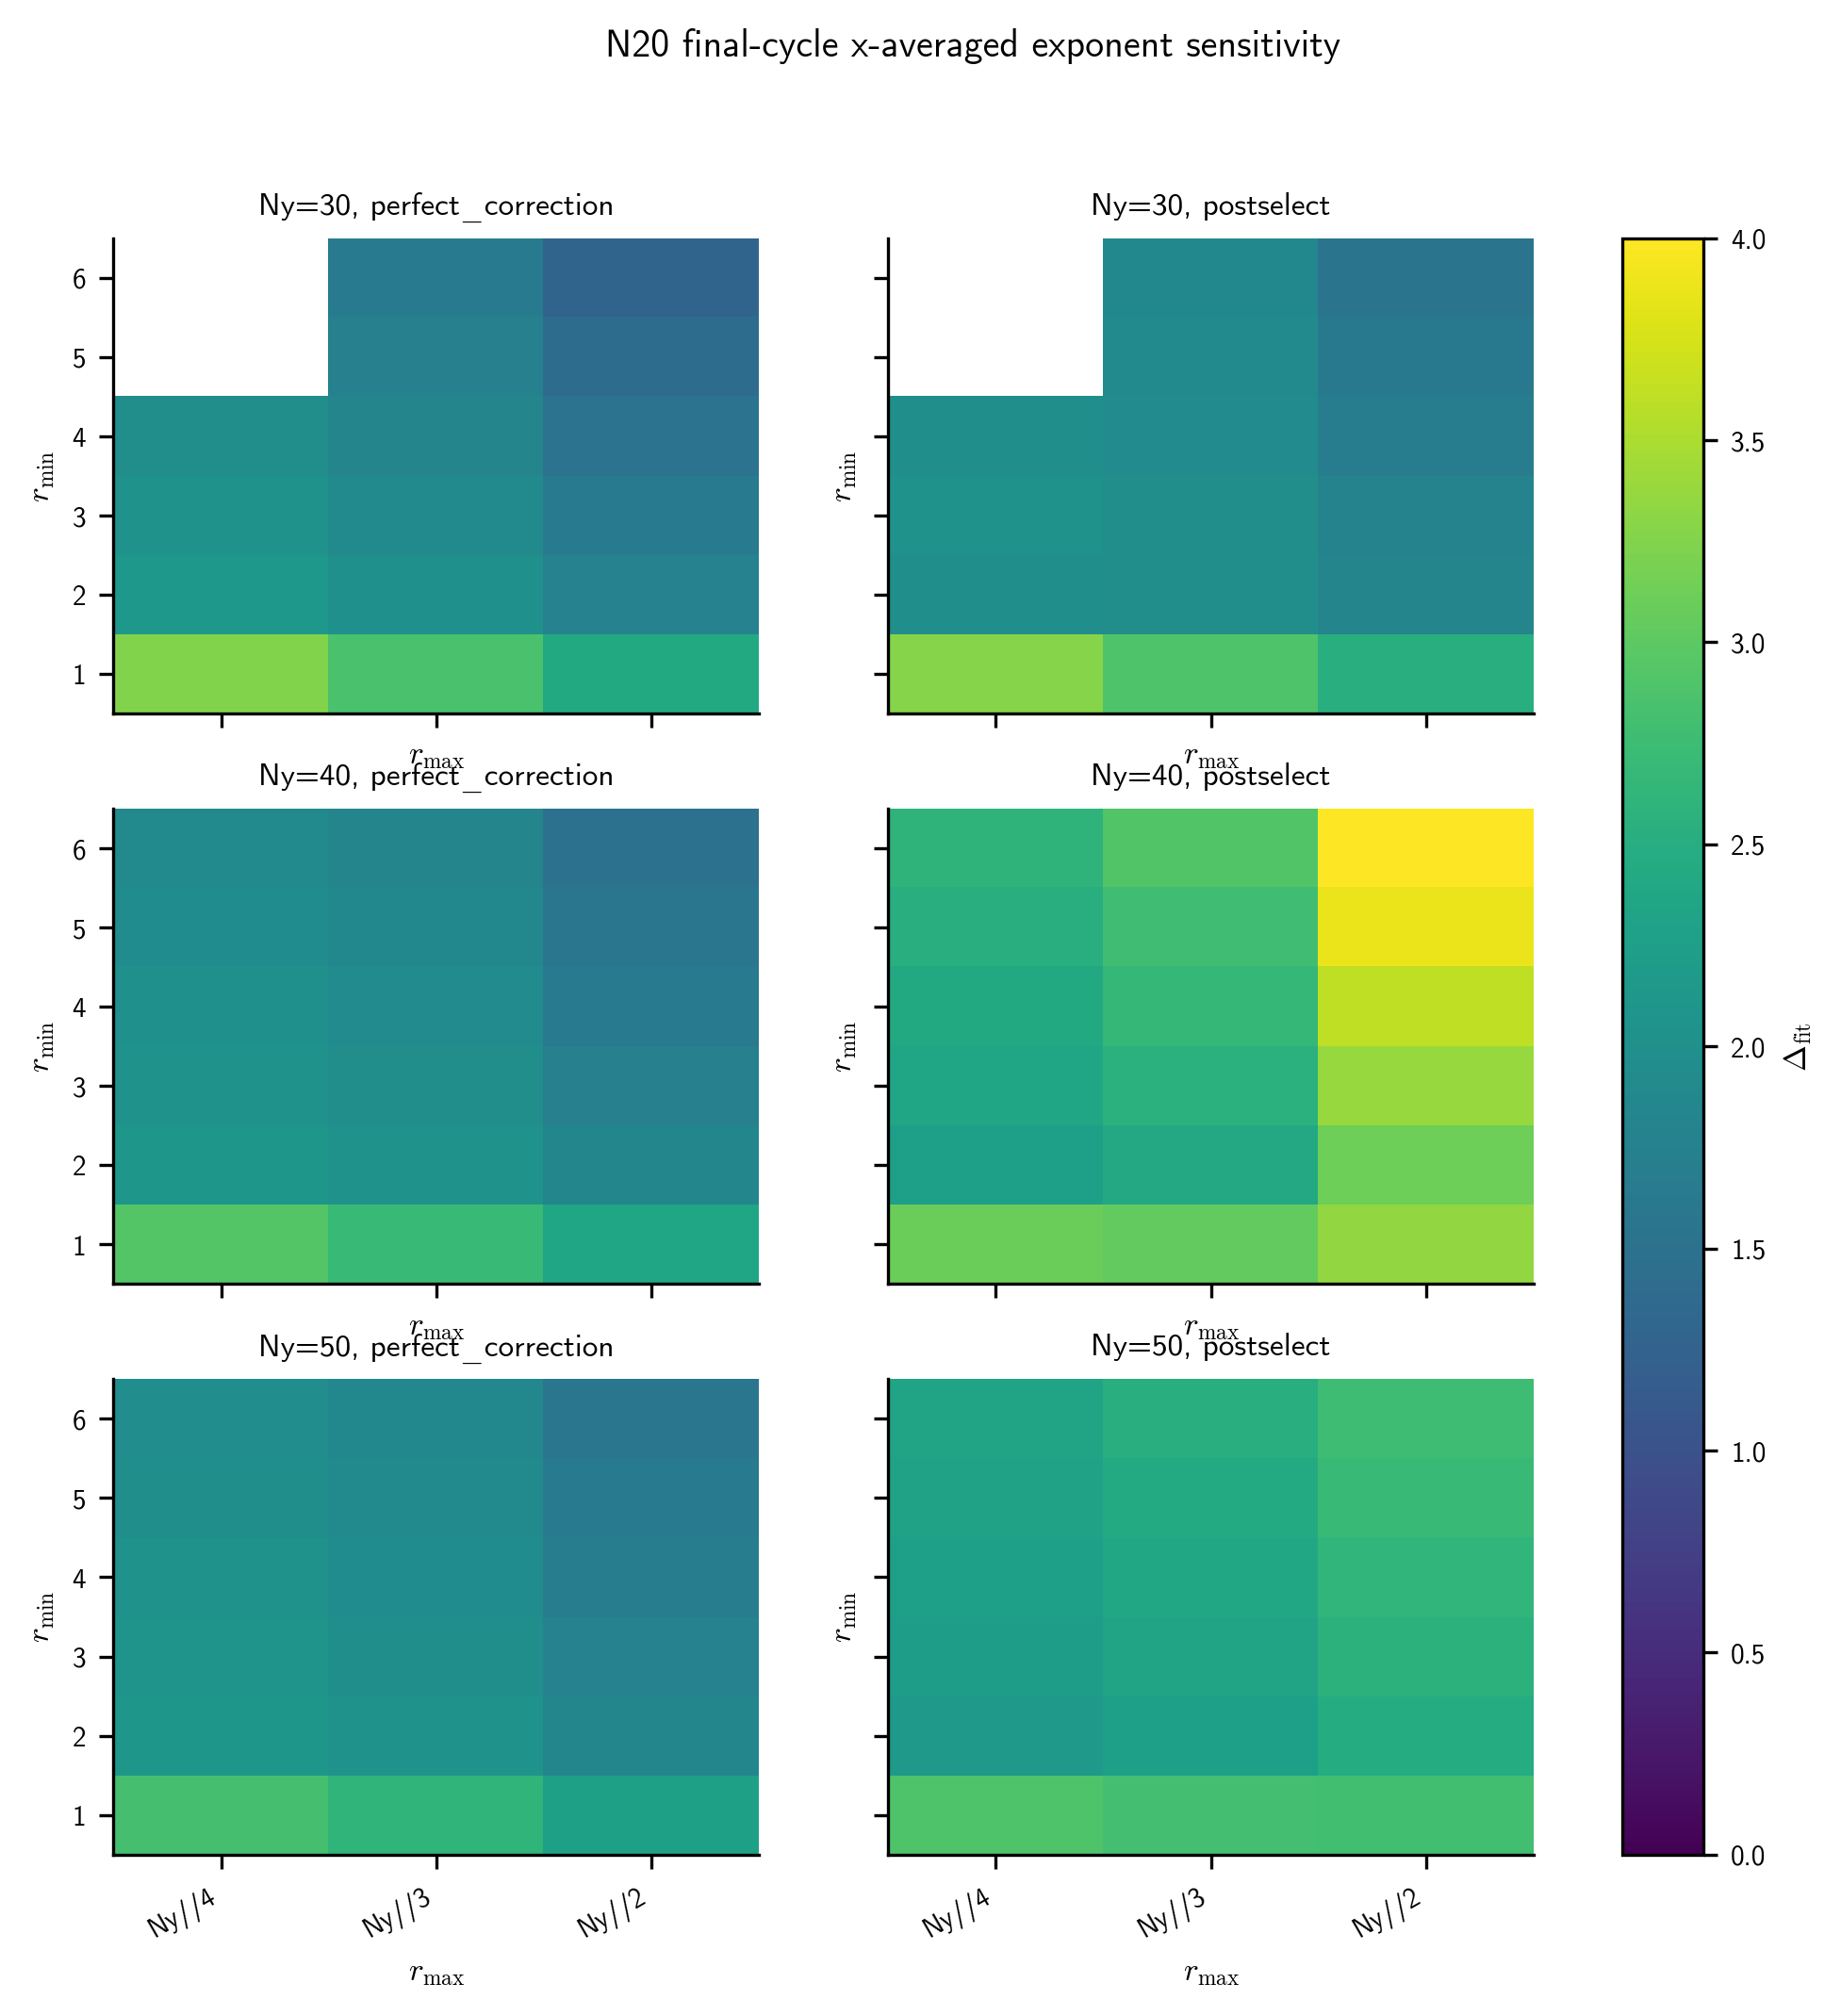

In [5]:
# Plot controls
SAVE_FIG = True
FIG_STEM = 'n20_final_cycle_window_heatmap'
TITLE = 'N20 final-cycle x-averaged exponent sensitivity'
CMAP = 'viridis'
VMIN = 0.0
VMAX = 4.0

final_n20 = n20_window_sweep.sort_values('cycle_label').groupby(['protocol', 'Ny', 'sample_index', 'r_min', 'r_max_label'], as_index=False).tail(1)
heat = final_n20.groupby(['protocol', 'Ny', 'r_min', 'r_max_label'], as_index=False).agg(
    exponent_mean=('correlator_exponent', 'mean'),
    exponent_std=('correlator_exponent', 'std'),
    r2_mean=('correlator_loglog_r2', 'mean'),
)
rmax_order = ['Ny//4', 'Ny//3', 'Ny//2']
fig, axes = plt.subplots(len(N20_NY_VALUES), len(N20_PROTOCOLS), figsize=(2.4 * WIDTH, 2.2 * WIDTH), sharex=True, sharey=True)
for i, ny in enumerate(N20_NY_VALUES):
    for j, protocol in enumerate(N20_PROTOCOLS):
        ax = axes[i, j]
        panel = heat[(heat['Ny'] == ny) & (heat['protocol'] == protocol)]
        pivot = panel.pivot(index='r_min', columns='r_max_label', values='exponent_mean').reindex(index=R_MIN_VALUES, columns=rmax_order)
        im = ax.imshow(pivot.to_numpy(), origin='lower', aspect='auto', cmap=CMAP, vmin=VMIN, vmax=VMAX)
        ax.set_title(f'Ny={ny}, {protocol}')
        ax.set_xticks(range(len(rmax_order)), rmax_order, rotation=30, ha='right')
        ax.set_yticks(range(len(R_MIN_VALUES)), R_MIN_VALUES)
        ax.set_xlabel(r'$r_{\max}$')
        ax.set_ylabel(r'$r_{\min}$')
fig.colorbar(im, ax=axes.ravel().tolist(), label=r'$\Delta_{\rm fit}$')
fig.suptitle(TITLE)
save_figure(fig, FIG_STEM, save=SAVE_FIG)
plt.show()


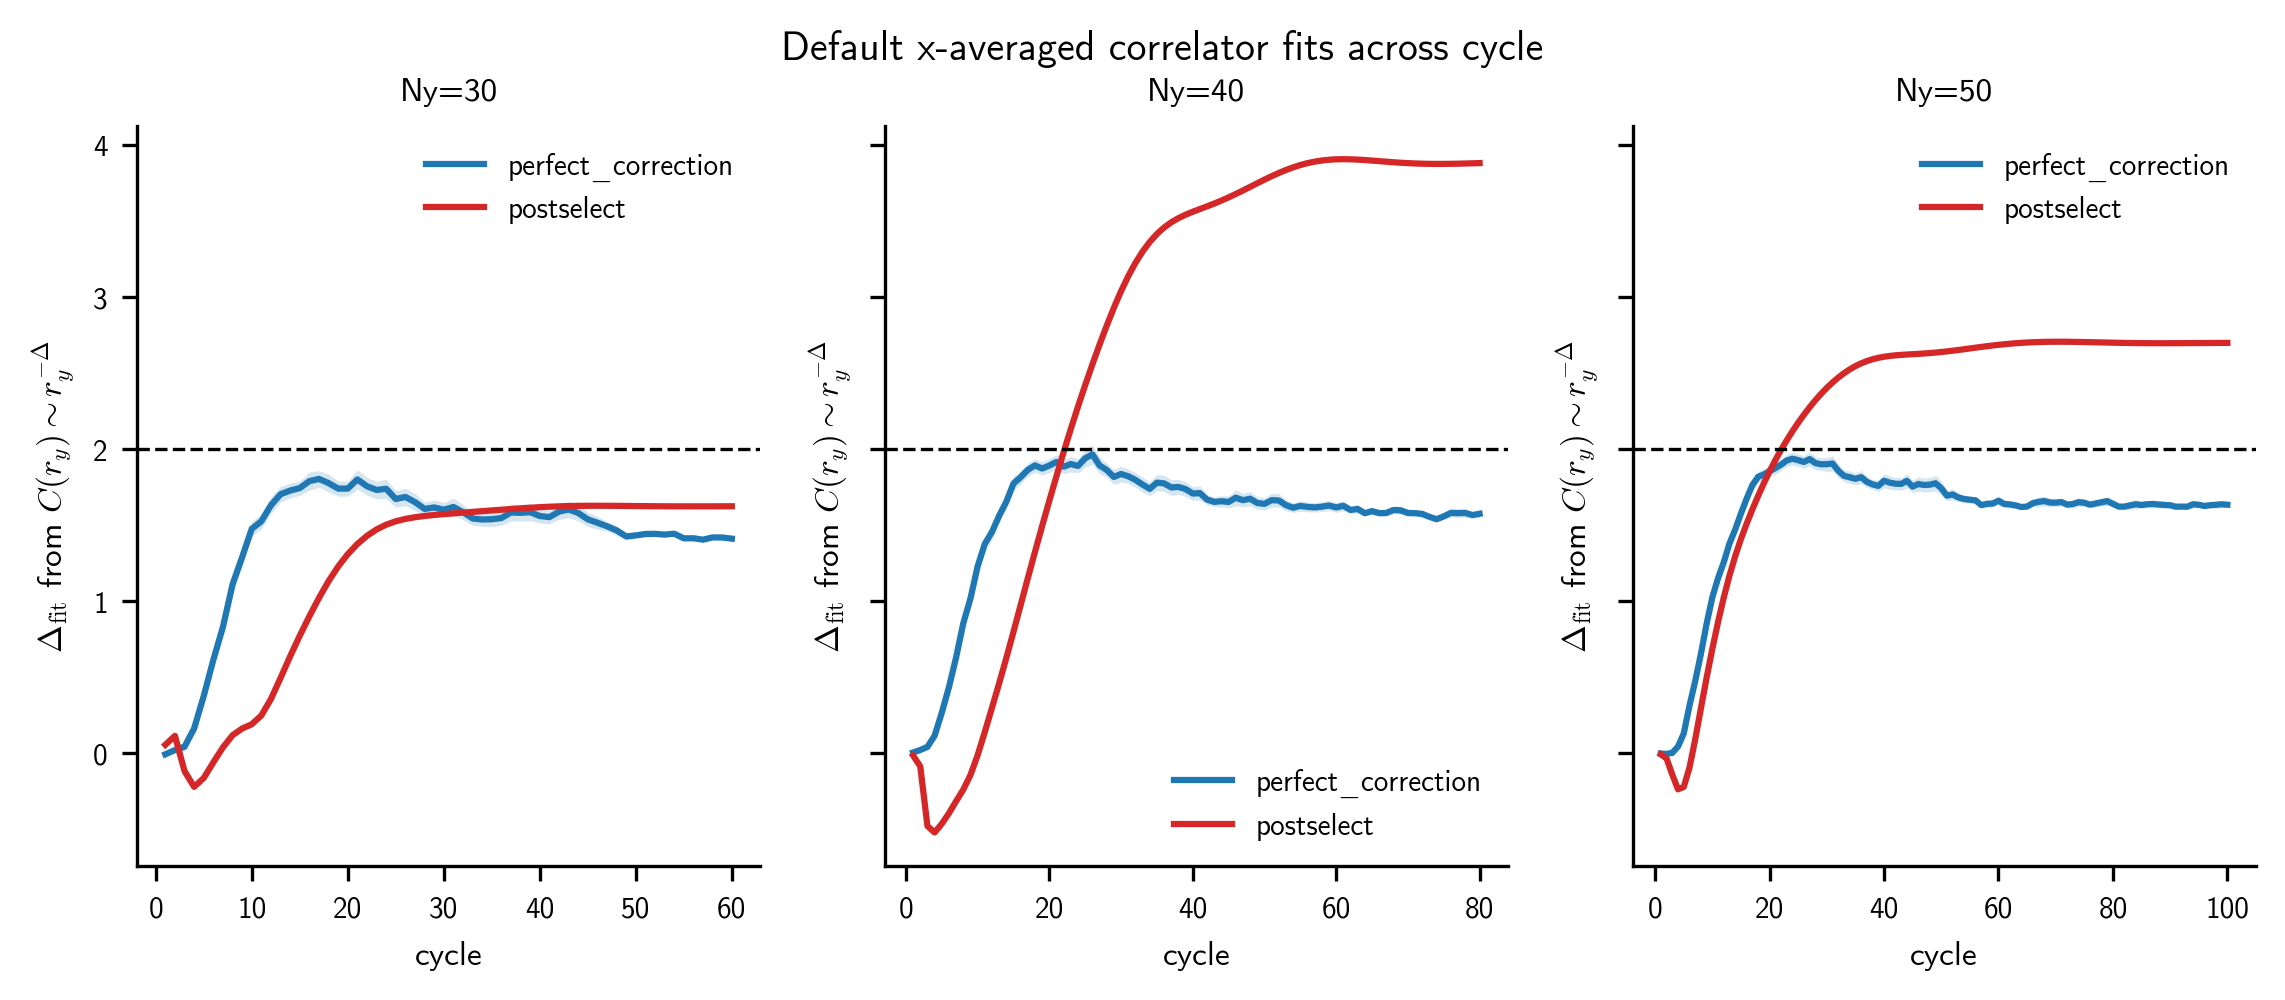

In [6]:
# Plot controls
SAVE_FIG = True
FIG_STEM = 'n20_default_protocol_comparison'
TITLE = 'Default x-averaged correlator fits across cycle'
Y_LABEL = r'$\Delta_{\rm fit}$ from $C(r_y)\sim r_y^{-\Delta}$'
LEGEND_LOC = 'best'
COLORS = {'perfect_correction': '#1f77b4', 'postselect': '#d62728'}

fig, axes = plt.subplots(1, len(N20_NY_VALUES), figsize=(2.7 * WIDTH, 0.95 * WIDTH), sharey=True)
if len(N20_NY_VALUES) == 1:
    axes = [axes]
default_df = n20_window_sweep[(n20_window_sweep['r_min'] == 5) & (n20_window_sweep['r_max_label'] == 'Ny//2')]
for ax, ny in zip(axes, N20_NY_VALUES):
    for protocol in N20_PROTOCOLS:
        panel = default_df[(default_df['Ny'] == ny) & (default_df['protocol'] == protocol)]
        stats = panel.groupby('cycle_label', as_index=False).agg(
            mean=('correlator_exponent', 'mean'),
            sem=('correlator_exponent', lambda s: float(s.std(ddof=1) / math.sqrt(len(s))) if len(s) > 1 else 0.0),
        )
        ax.plot(stats['cycle_label'], stats['mean'], color=COLORS[protocol], label=protocol)
        ax.fill_between(stats['cycle_label'], stats['mean'] - stats['sem'], stats['mean'] + stats['sem'], color=COLORS[protocol], alpha=0.18, linewidth=0)
    ax.axhline(TARGET_EXPONENT, color='k', linewidth=0.8, linestyle='--')
    ax.set_title(f'Ny={ny}')
    ax.set_xlabel('cycle')
    ax.set_ylabel(Y_LABEL)
    ax.legend(loc=LEGEND_LOC, frameon=False)
fig.suptitle(TITLE)
save_figure(fig, FIG_STEM, save=SAVE_FIG)
plt.show()


## N16 Raw Covariance Wall-Localized Correlators


In [7]:
def snapshot_records() -> list[dict[str, Any]]:
    manifest = json.loads(N16_MANIFEST_PATH.read_text())
    records = []
    for entry in manifest['results']:
        nx = int(entry['Nx'])
        ny = int(entry['Ny'])
        nsh = int(entry['nshell'])
        if nx != 16 or ny not in N16_NY_VALUES or nsh not in N16_NSHELL_VALUES:
            continue
        run_dir = N16_SNAPSHOT_ROOT / Path(entry['run_dir_relative']).relative_to('pure_state_covariance_snapshots')
        manifest_path = run_dir / 'manifest.json'
        run_manifest = json.loads(manifest_path.read_text())
        shard_records = []
        for shard_idx, shard in sorted(run_manifest['shards'].items(), key=lambda kv: int(kv[0])):
            shard_path = run_dir / shard['filename']
            if not shard_path.exists():
                raise FileNotFoundError(shard_path)
            expected_shape = tuple(int(v) for v in shard['shape'])
            arr = np.load(shard_path, mmap_mode='r')
            if tuple(arr.shape) != expected_shape:
                raise RuntimeError(f'shard shape mismatch for {shard_path}: {arr.shape} != {expected_shape}')
            shard_records.append({
                'shard_index': int(shard_idx),
                'path': shard_path,
                'sample_start': int(shard['sample_start']),
                'sample_stop': int(shard['sample_stop']),
                'shape': expected_shape,
            })
        records.append({
            'source': 'N16_raw_covariance_snapshots',
            'protocol': entry['protocol'],
            'Nx': nx,
            'Ny': ny,
            'nshell': nsh,
            'samples': int(entry['samples']),
            'snapshot_cycles': [int(c) for c in entry['snapshot_cycles']],
            'run_dir': run_dir,
            'manifest_path': manifest_path,
            'shards': shard_records,
        })
    return sorted(records, key=lambda r: (r['Ny'], r['nshell']))

n16_records = snapshot_records()
if not n16_records:
    raise RuntimeError('No N16 pure-state snapshot records found.')
for rec in n16_records:
    if rec['snapshot_cycles'] != N16_SNAPSHOT_CYCLES:
        raise RuntimeError(f'unexpected snapshot cycles for {rec["run_dir"]}: {rec["snapshot_cycles"]}')
    windows = x_windows_for_geometry(rec['Nx'], radius=WALL_RADIUS)
    print(f"[source] N{rec['Nx']}x{rec['Ny']} nsh{rec['nshell']} samples={rec['samples']} cycles={rec['snapshot_cycles']} walls={domain_wall_locations(rec['Nx'])} windows={ {k: v.tolist() for k, v in windows.items()} }")


[source] N16x30 nsh1 samples=10 cycles=[5, 10, 20, 50] walls=(4, 12) windows={'full_x': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], 'left_wall_window': [3, 4, 5], 'right_wall_window': [11, 12, 13], 'both_walls': [3, 4, 5, 11, 12, 13], 'topological_bulk': [6, 7, 8, 9, 10], 'nonwall_control': [0, 1, 2, 6, 7, 8, 9, 10, 14, 15]}
[source] N16x30 nsh2 samples=10 cycles=[5, 10, 20, 50] walls=(4, 12) windows={'full_x': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], 'left_wall_window': [3, 4, 5], 'right_wall_window': [11, 12, 13], 'both_walls': [3, 4, 5, 11, 12, 13], 'topological_bulk': [6, 7, 8, 9, 10], 'nonwall_control': [0, 1, 2, 6, 7, 8, 9, 10, 14, 15]}
[source] N16x40 nsh1 samples=10 cycles=[5, 10, 20, 50] walls=(4, 12) windows={'full_x': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], 'left_wall_window': [3, 4, 5], 'right_wall_window': [11, 12, 13], 'both_walls': [3, 4, 5, 11, 12, 13], 'topological_bulk': [6, 7, 8, 9, 10], 'nonwall_control': [0, 1, 2, 6, 7, 8,

In [8]:
def window_pair_indices(nx: int, ny: int, x_values: np.ndarray, ry_values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    x_values = np.asarray(x_values, dtype=np.int64)
    ry_values = np.asarray(ry_values, dtype=np.int64)
    y = np.arange(ny, dtype=np.int64)
    mu = np.arange(2, dtype=np.int64)
    nu = np.arange(2, dtype=np.int64)
    left_by_ry = []
    right_by_ry = []
    for ry in ry_values:
        left = []
        right = []
        for x in x_values:
            for yy in y:
                yy2 = (int(yy) + int(ry)) % ny
                for m in mu:
                    for n in nu:
                        left.append(int(m + 2 * x + 2 * nx * yy))
                        right.append(int(n + 2 * x + 2 * nx * yy2))
        left_by_ry.append(np.asarray(left, dtype=np.int64))
        right_by_ry.append(np.asarray(right, dtype=np.int64))
    return np.stack(left_by_ry, axis=0), np.stack(right_by_ry, axis=0)


def square_correlator_one_g(g: np.ndarray, *, nx: int, ny: int, left_idx: np.ndarray, right_idx: np.ndarray, x_count: int) -> np.ndarray:
    out = np.empty(left_idx.shape[0], dtype=np.float64)
    for ridx in range(left_idx.shape[0]):
        vals = g[left_idx[ridx], right_idx[ridx]]
        same = left_idx[ridx] == right_idx[ridx]
        if np.any(same):
            vals = vals.copy()
            vals[same] += 1.0
        vals = 0.5 * vals
        out[ridx] = float(np.sum(np.abs(vals) ** 2) / float(2 * int(x_count) * int(ny)))
    return out

curve_rows = []
for rec in n16_records:
    nx, ny = rec['Nx'], rec['Ny']
    ry_values = np.arange(ny // 2 + 1, dtype=np.int64)
    windows = x_windows_for_geometry(nx, radius=WALL_RADIUS)
    pair_cache = {
        name: (*window_pair_indices(nx, ny, xs, ry_values), len(xs))
        for name, xs in windows.items()
    }
    for shard in rec['shards']:
        data = np.load(shard['path'], mmap_mode='r')
        if data.ndim != 4:
            raise RuntimeError(f'expected snapshot shard shape (sample, snapshot, N, N), got {data.shape}')
        for local_sample in range(data.shape[0]):
            sample_index = int(shard['sample_start'] + local_sample)
            for cycle_pos, cycle_label in enumerate(rec['snapshot_cycles']):
                g = data[local_sample, cycle_pos]
                for window_name, (left_idx, right_idx, x_count) in pair_cache.items():
                    corr = square_correlator_one_g(g, nx=nx, ny=ny, left_idx=left_idx, right_idx=right_idx, x_count=x_count)
                    curve_rows.extend({
                        'source': rec['source'],
                        'protocol': rec['protocol'],
                        'Nx': nx,
                        'Ny': ny,
                        'nshell': rec['nshell'],
                        'sample_index': sample_index,
                        'cycle_label': int(cycle_label),
                        'x_window': window_name,
                        'ry': int(ry),
                        'square_correlator': float(value),
                    } for ry, value in zip(ry_values, corr))

n16_curves = pd.DataFrame(curve_rows)
n16_curves_path = TABLE_DIR / 'n16_wall_localized_correlator_curves.csv'
save_dataframe(n16_curves, n16_curves_path)
print(f'[saved] {n16_curves_path} rows={len(n16_curves)}')
display(n16_curves.head())


[saved] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/correlator_scaling_diagnostics/tables/n16_wall_localized_correlator_curves.csv rows=17760


,source,protocol,Nx,Ny,nshell,sample_index,cycle_label,x_window,ry,square_correlator
0,N16_raw_covariance_snapshots,perfect_correction,16,30,1,0,5,full_x,0,0.421621
1,N16_raw_covariance_snapshots,perfect_correction,16,30,1,0,5,full_x,1,0.019052
2,N16_raw_covariance_snapshots,perfect_correction,16,30,1,0,5,full_x,2,0.000443
3,N16_raw_covariance_snapshots,perfect_correction,16,30,1,0,5,full_x,3,0.000165
4,N16_raw_covariance_snapshots,perfect_correction,16,30,1,0,5,full_x,4,0.000070


In [9]:
n16_fit_frames = []
for (ny, nsh, protocol, sample, cycle, window), group in n16_curves.groupby(['Ny', 'nshell', 'protocol', 'sample_index', 'cycle_label', 'x_window']):
    values = group.sort_values('ry')['square_correlator'].to_numpy(dtype=np.float64)[None, None, :]
    ry_values = group.sort_values('ry')['ry'].to_numpy(dtype=np.int64)
    fit_df = fit_loglog_curve_grid(values, ry_values, int(ny))
    fit_df['source'] = 'N16_raw_covariance_snapshots'
    fit_df['protocol'] = protocol
    fit_df['Nx'] = 16
    fit_df['Ny'] = int(ny)
    fit_df['nshell'] = int(nsh)
    fit_df['sample_index'] = int(sample)
    fit_df['cycle_label'] = int(cycle)
    fit_df['x_window'] = window
    n16_fit_frames.append(fit_df.drop(columns=['cycle_pos']))

n16_fit_sweep = pd.concat(n16_fit_frames, ignore_index=True)
n16_fit_sweep['abs_error_from_2'] = np.abs(n16_fit_sweep['correlator_exponent'] - TARGET_EXPONENT)
n16_fit_path = TABLE_DIR / 'n16_wall_localized_fit_sweep.csv'
save_dataframe(n16_fit_sweep, n16_fit_path)
print(f'[saved] {n16_fit_path} rows={len(n16_fit_sweep)}')
display(n16_fit_sweep.head())


[saved] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/correlator_scaling_diagnostics/tables/n16_wall_localized_fit_sweep.csv rows=16320


,sample_index,r_min,r_max,r_max_label,n_fit_ry,correlator_loglog_slope,correlator_exponent,correlator_loglog_intercept,correlator_loglog_slope_stderr,correlator_loglog_r2,source,protocol,Nx,Ny,nshell,cycle_label,x_window,abs_error_from_2
0,0,1,7,Ny//4,7,-2.921812,2.921812,-4.430573,0.139143,0.988788,N16_raw_covariance_snapshots,perfect_correction,16,30,1,5,both_walls,0.921812
1,0,1,10,Ny//3,10,-2.553906,2.553906,-4.737749,0.185631,0.959449,N16_raw_covariance_snapshots,perfect_correction,16,30,1,5,both_walls,0.553906
2,0,1,15,Ny//2,15,-1.837945,1.837945,-5.508227,0.257964,0.796120,N16_raw_covariance_snapshots,perfect_correction,16,30,1,5,both_walls,0.162055
3,0,2,7,Ny//4,6,-2.535913,2.535913,-5.027923,0.048126,0.998561,N16_raw_covariance_snapshots,perfect_correction,16,30,1,5,both_walls,0.535913
4,0,2,10,Ny//3,9,-2.115246,2.115246,-5.540765,0.174142,0.954705,N16_raw_covariance_snapshots,perfect_correction,16,30,1,5,both_walls,0.115246


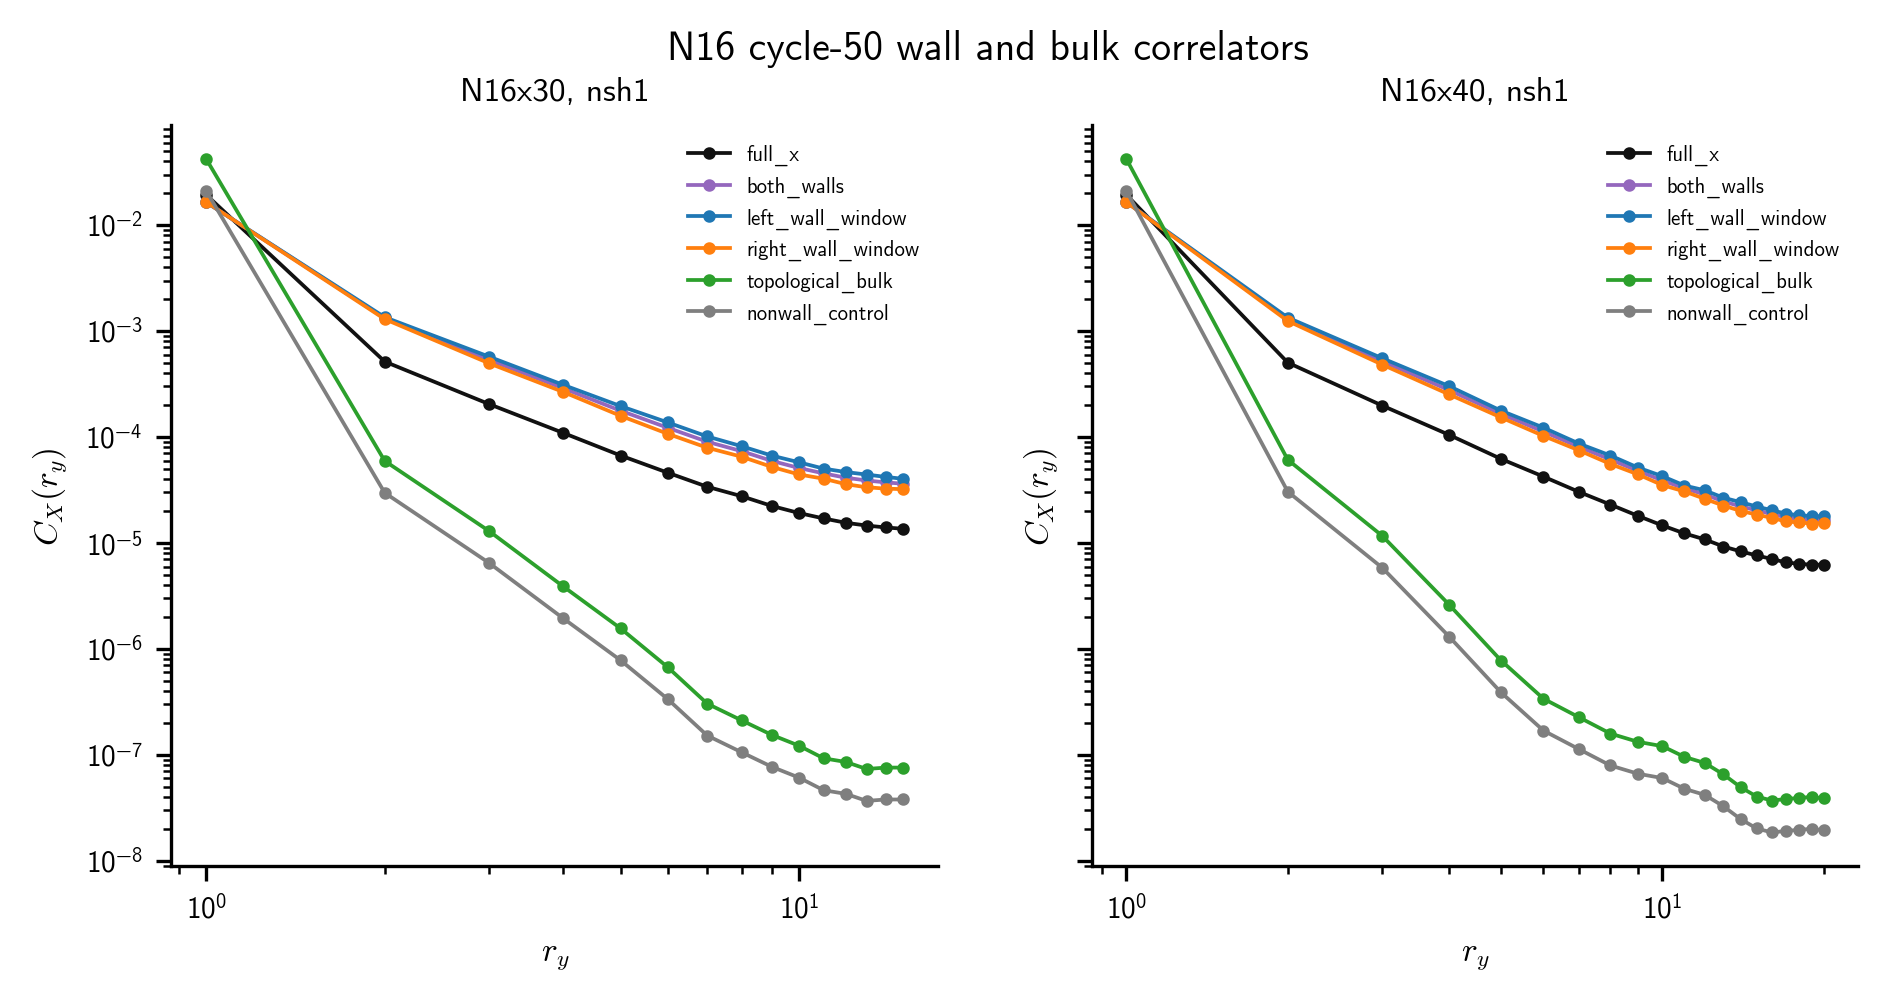

In [10]:
# Plot controls
SAVE_FIG = True
FIG_STEM = 'n16_wall_bulk_correlator_curves_cycle50'
TITLE = 'N16 cycle-50 wall and bulk correlators'
Y_SCALE = 'log'
X_SCALE = 'log'
LEGEND_LOC = 'best'
WINDOW_ORDER = ['full_x', 'both_walls', 'left_wall_window', 'right_wall_window', 'topological_bulk', 'nonwall_control']
COLORS = {
    'full_x': '#111111',
    'both_walls': '#9467bd',
    'left_wall_window': '#1f77b4',
    'right_wall_window': '#ff7f0e',
    'topological_bulk': '#2ca02c',
    'nonwall_control': '#7f7f7f',
}

plot_df = n16_curves[(n16_curves['cycle_label'] == 50) & (n16_curves['nshell'] == 1)]
fig, axes = plt.subplots(1, len(N16_NY_VALUES), figsize=(2.15 * WIDTH, 0.95 * WIDTH), sharey=True)
if len(N16_NY_VALUES) == 1:
    axes = [axes]
for ax, ny in zip(axes, N16_NY_VALUES):
    for window in WINDOW_ORDER:
        panel = plot_df[(plot_df['Ny'] == ny) & (plot_df['x_window'] == window)]
        stats = panel.groupby('ry', as_index=False).agg(mean=('square_correlator', 'mean'))
        stats = stats[stats['ry'] >= 1]
        ax.plot(stats['ry'], stats['mean'], marker='o', markersize=2.0, linewidth=0.9, color=COLORS[window], label=window)
    ax.set_xscale(X_SCALE)
    ax.set_yscale(Y_SCALE)
    ax.set_title(f'N16x{ny}, nsh1')
    ax.set_xlabel(r'$r_y$')
    ax.set_ylabel(r'$C_X(r_y)$')
    ax.legend(loc=LEGEND_LOC, frameon=False, fontsize=5)
fig.suptitle(TITLE)
save_figure(fig, FIG_STEM, save=SAVE_FIG)
plt.show()


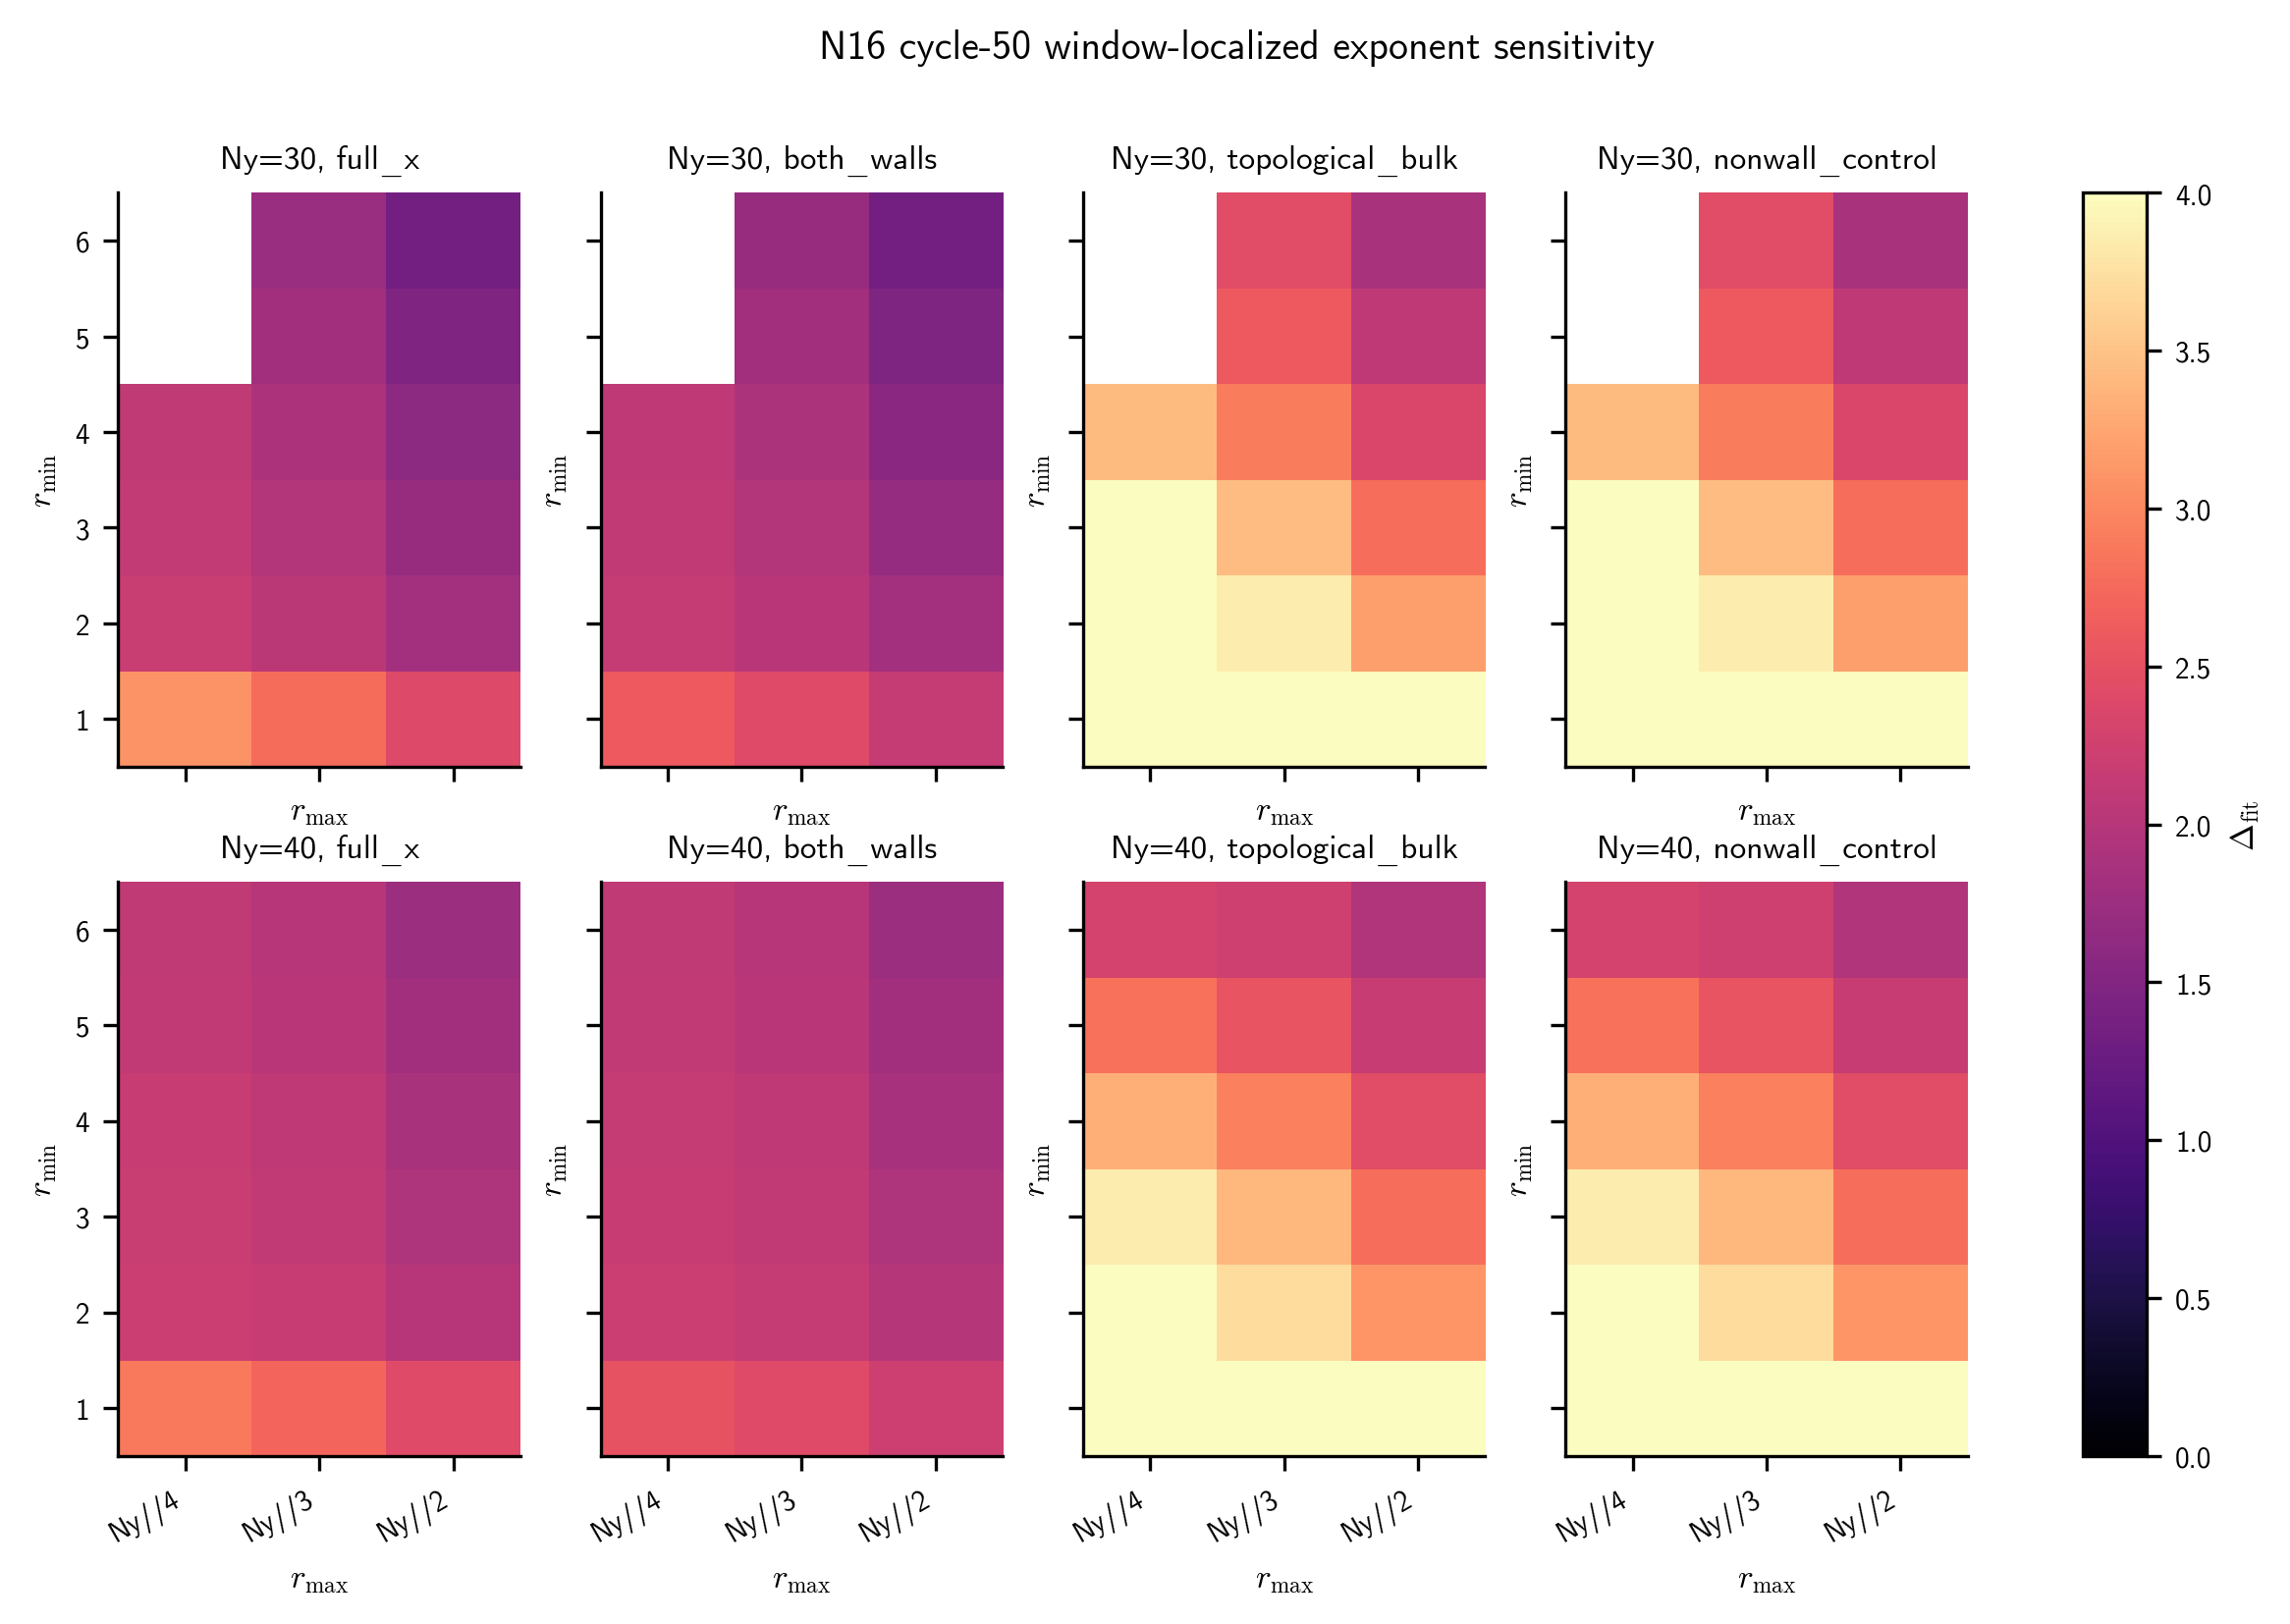

In [11]:
# Plot controls
SAVE_FIG = True
FIG_STEM = 'n16_window_fit_heatmap_cycle50'
TITLE = 'N16 cycle-50 window-localized exponent sensitivity'
CMAP = 'magma'
VMIN = 0.0
VMAX = 4.0
WINDOWS_TO_SHOW = ['full_x', 'both_walls', 'topological_bulk', 'nonwall_control']

final_n16 = n16_fit_sweep[(n16_fit_sweep['cycle_label'] == 50) & (n16_fit_sweep['nshell'] == 1)]
summary = final_n16.groupby(['Ny', 'x_window', 'r_min', 'r_max_label'], as_index=False).agg(
    exponent_mean=('correlator_exponent', 'mean'),
    exponent_std=('correlator_exponent', 'std'),
    r2_mean=('correlator_loglog_r2', 'mean'),
)
rmax_order = ['Ny//4', 'Ny//3', 'Ny//2']
fig, axes = plt.subplots(len(N16_NY_VALUES), len(WINDOWS_TO_SHOW), figsize=(3.0 * WIDTH, 1.65 * WIDTH), sharex=True, sharey=True)
for i, ny in enumerate(N16_NY_VALUES):
    for j, window in enumerate(WINDOWS_TO_SHOW):
        ax = axes[i, j]
        panel = summary[(summary['Ny'] == ny) & (summary['x_window'] == window)]
        pivot = panel.pivot(index='r_min', columns='r_max_label', values='exponent_mean').reindex(index=R_MIN_VALUES, columns=rmax_order)
        im = ax.imshow(pivot.to_numpy(), origin='lower', aspect='auto', cmap=CMAP, vmin=VMIN, vmax=VMAX)
        ax.set_title(f'Ny={ny}, {window}')
        ax.set_xticks(range(len(rmax_order)), rmax_order, rotation=30, ha='right')
        ax.set_yticks(range(len(R_MIN_VALUES)), R_MIN_VALUES)
        ax.set_xlabel(r'$r_{\max}$')
        ax.set_ylabel(r'$r_{\min}$')
fig.colorbar(im, ax=axes.ravel().tolist(), label=r'$\Delta_{\rm fit}$')
fig.suptitle(TITLE)
save_figure(fig, FIG_STEM, save=SAVE_FIG)
plt.show()


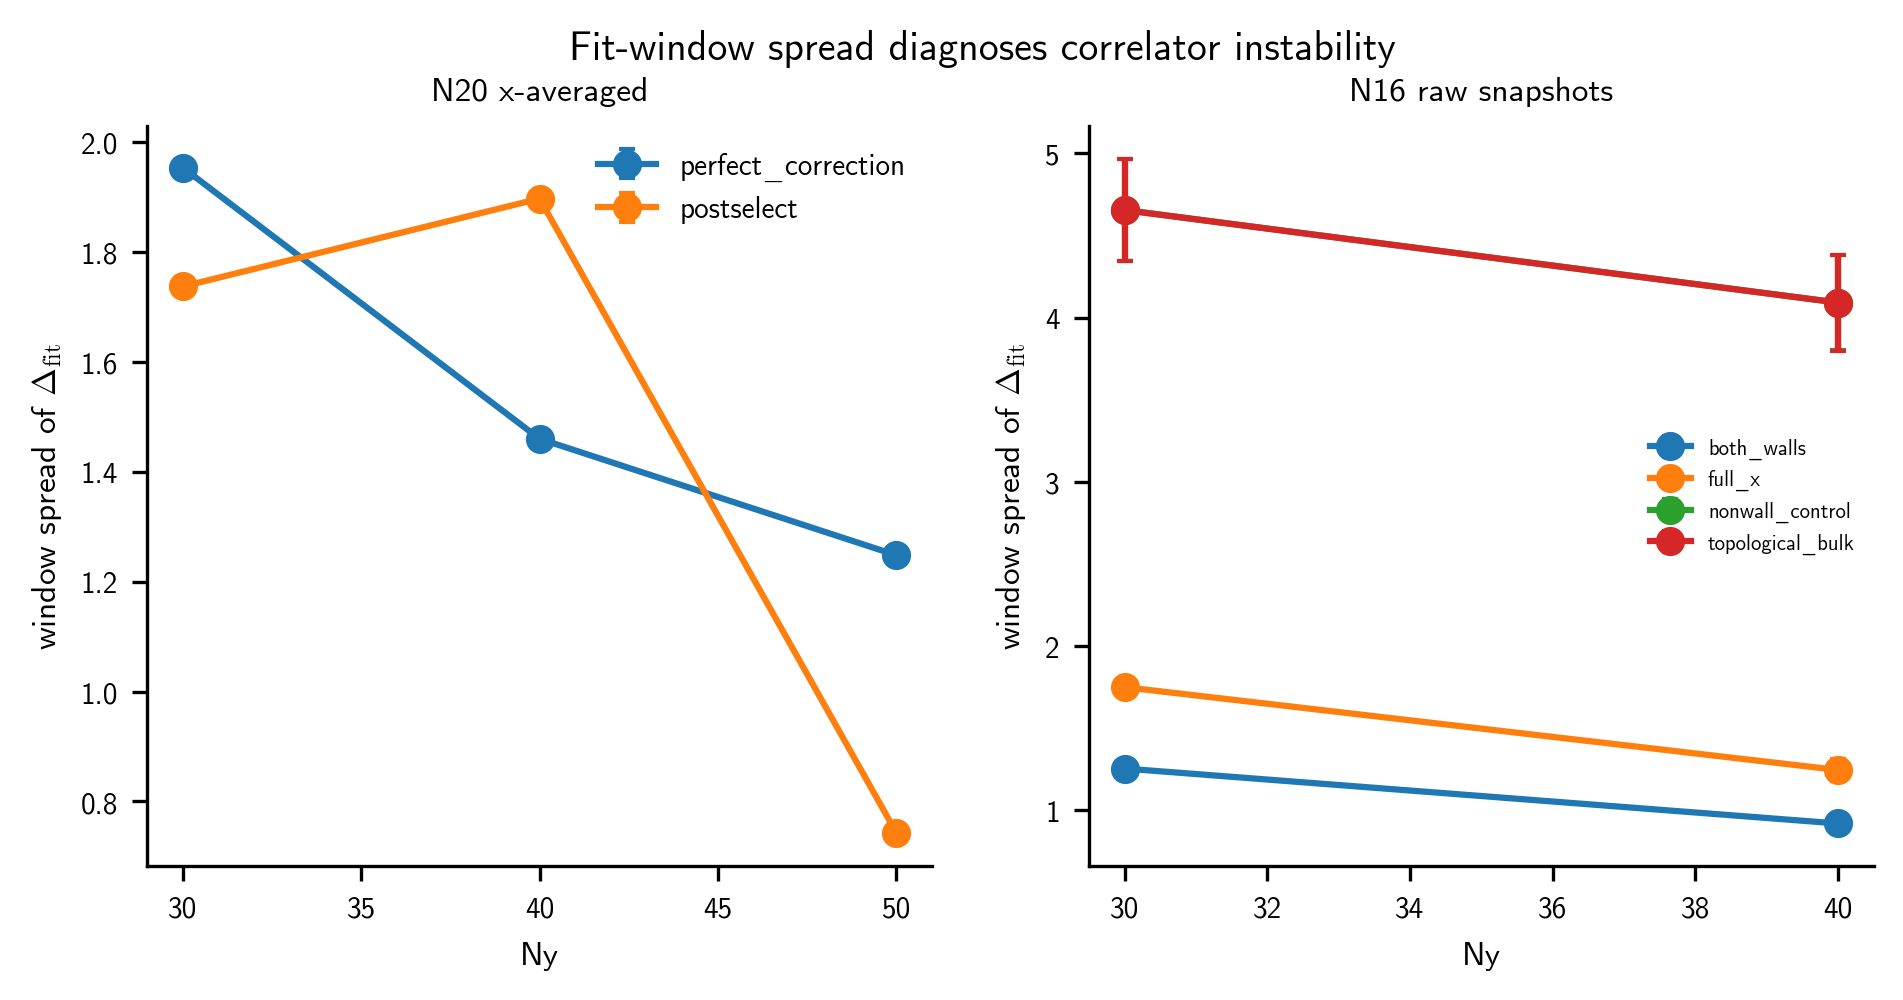

In [12]:
# Plot controls
SAVE_FIG = True
FIG_STEM = 'n20_n16_window_spread_summary'
TITLE = 'Fit-window spread diagnoses correlator instability'
Y_LABEL = r'window spread of $\Delta_{\rm fit}$'
LEGEND_LOC = 'best'

n20_spread = final_n20.groupby(['protocol', 'Ny', 'sample_index'], as_index=False).agg(
    exponent_min=('correlator_exponent', 'min'),
    exponent_max=('correlator_exponent', 'max'),
)
n20_spread['spread'] = n20_spread['exponent_max'] - n20_spread['exponent_min']
n20_spread_summary = n20_spread.groupby(['protocol', 'Ny'], as_index=False).agg(mean_spread=('spread', 'mean'), sem_spread=('spread', lambda s: float(s.std(ddof=1) / math.sqrt(len(s))) if len(s) > 1 else 0.0))

n16_spread = final_n16.groupby(['Ny', 'nshell', 'sample_index', 'x_window'], as_index=False).agg(
    exponent_min=('correlator_exponent', 'min'),
    exponent_max=('correlator_exponent', 'max'),
)
n16_spread['spread'] = n16_spread['exponent_max'] - n16_spread['exponent_min']
n16_spread_summary = n16_spread[(n16_spread['nshell'] == 1) & (n16_spread['x_window'].isin(['full_x', 'both_walls', 'topological_bulk', 'nonwall_control']))].groupby(['Ny', 'x_window'], as_index=False).agg(mean_spread=('spread', 'mean'), sem_spread=('spread', lambda s: float(s.std(ddof=1) / math.sqrt(len(s))) if len(s) > 1 else 0.0))

fig, axes = plt.subplots(1, 2, figsize=(2.2 * WIDTH, 0.95 * WIDTH))
for protocol, panel in n20_spread_summary.groupby('protocol'):
    axes[0].errorbar(panel['Ny'], panel['mean_spread'], yerr=panel['sem_spread'], marker='o', capsize=2, label=protocol)
axes[0].set_title('N20 x-averaged')
axes[0].set_xlabel('Ny')
axes[0].set_ylabel(Y_LABEL)
axes[0].legend(loc=LEGEND_LOC, frameon=False)
for window, panel in n16_spread_summary.groupby('x_window'):
    axes[1].errorbar(panel['Ny'], panel['mean_spread'], yerr=panel['sem_spread'], marker='o', capsize=2, label=window)
axes[1].set_title('N16 raw snapshots')
axes[1].set_xlabel('Ny')
axes[1].set_ylabel(Y_LABEL)
axes[1].legend(loc=LEGEND_LOC, frameon=False, fontsize=5)
fig.suptitle(TITLE)
save_figure(fig, FIG_STEM, save=SAVE_FIG)
plt.show()


## Half-Filled Flattened-Hamiltonian Equilibrium Reference

Construct the half-filled ground state of the flattened equilibrium Hamiltonian using the same OW-projector convention as `flattened_hamiltonian_finite_size_scaling.ipynb`, then run the same correlator-window diagnostics used above.


In [13]:
# Equilibrium flattened-H reference controls
FLAT_ALPHA_1 = 1
FLAT_ALPHA_2 = 30
FLAT_TRIAL_ORBITAL = 'X'
FLAT_DW = True
FLAT_DW_TRUNCATION = True
FLAT_NSHELL = 1
FLAT_NX = 20
FLAT_ENTROPY_REFERENCE_PATH = REPO_ROOT / 'notebooks' / 'flattened_hamiltonian_analysis' / 'data' / 'flattened_hamiltonian_finite_size_slope_vs_filling.csv'

SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from fgtn.classA_U1FGTN import classA_U1FGTN


def build_flattened_hamiltonian_reference(model, trial_orbital=FLAT_TRIAL_ORBITAL, dw_truncation=FLAT_DW_TRUNCATION):
    n_layer = 2 * model.Nx * model.Ny
    model.construct_OW_projectors(
        nshell=model.nshell,
        DW=model.DW,
        trial_orbitals=trial_orbital,
        dw_truncation=dw_truncation,
    )
    wa_p = model.WF_Ap.reshape(n_layer, -1)
    wb_p = model.WF_Bp.reshape(n_layer, -1)
    wa_m = model.WF_Am.reshape(n_layer, -1)
    wb_m = model.WF_Bm.reshape(n_layer, -1)
    h_flat = wa_p @ wa_p.conj().T + wb_p @ wb_p.conj().T - wa_m @ wa_m.conj().T - wb_m @ wb_m.conj().T
    return 0.5 * (h_flat + h_flat.conj().T)


def occupation_projector(evecs: np.ndarray, n_occ: int) -> np.ndarray:
    u_occ = np.asarray(evecs[:, :int(n_occ)], dtype=np.complex128)
    return u_occ @ u_occ.conj().T


def covariance_pm1_from_projector(p_occ: np.ndarray) -> np.ndarray:
    p_occ = np.asarray(p_occ, dtype=np.complex128)
    return 2.0 * p_occ.conj() - np.eye(p_occ.shape[0], dtype=np.complex128)


def flattened_half_fill_state(nx: int, ny: int, nshell: int = FLAT_NSHELL) -> dict[str, Any]:
    model = classA_U1FGTN(
        int(nx),
        int(ny),
        nshell=nshell,
        DW=FLAT_DW,
        alpha_1=FLAT_ALPHA_1,
        alpha_2=FLAT_ALPHA_2,
    )
    h_flat = build_flattened_hamiltonian_reference(model)
    evals, evecs = np.linalg.eigh(h_flat)
    n_layer = h_flat.shape[0]
    n_occ = n_layer // 2
    p_occ = occupation_projector(evecs, n_occ)
    g_pm1 = covariance_pm1_from_projector(p_occ)
    gap = float(evals[n_occ] - evals[n_occ - 1]) if 0 < n_occ < len(evals) else np.nan
    return {
        'model': model,
        'evals': evals,
        'P_occ': p_occ,
        'G_pm1': g_pm1,
        'n_occ': int(n_occ),
        'Nlayer': int(n_layer),
        'half_fill_gap': gap,
    }


def full_x_y_block_indices(nx: int, ny: int, ay: int, y0: int = 0) -> np.ndarray:
    ay = int(ay)
    y0 = int(y0) % int(ny)
    idx = []
    for y in (np.arange(ay, dtype=int) + y0) % int(ny):
        base = 2 * int(nx) * int(y)
        for x in range(int(nx)):
            idx.append(base + 2 * x)
            idx.append(base + 2 * x + 1)
    return np.asarray(idx, dtype=np.int64)


def entropy_from_projector_submatrix(p_sub: np.ndarray) -> float:
    evals = np.linalg.eigvalsh(np.asarray(p_sub, dtype=np.complex128))
    evals = np.clip(np.real_if_close(evals), 1e-12, 1.0 - 1e-12)
    return float(np.sum(-(evals * np.log(evals) + (1.0 - evals) * np.log(1.0 - evals))))


def logchord_values(ay_values: np.ndarray, ny: int) -> np.ndarray:
    ay_values = np.asarray(ay_values, dtype=np.float64)
    out = np.full(ay_values.shape, np.nan, dtype=np.float64)
    mask = ay_values > 0
    out[mask] = np.log((float(ny) / np.pi) * np.sin(np.pi * ay_values[mask] / float(ny)))
    return out


def fit_entropy_logchord(ay_values: np.ndarray, entropy_values: np.ndarray, ny: int, ay_min: int = 8) -> dict[str, float]:
    ay_values = np.asarray(ay_values, dtype=np.int64)
    entropy_values = np.asarray(entropy_values, dtype=np.float64)
    x = logchord_values(ay_values, ny)
    mask = (ay_values >= int(ay_min)) & (ay_values <= int(ny // 2)) & np.isfinite(x) & np.isfinite(entropy_values)
    if int(np.count_nonzero(mask)) < 3:
        return {'entropy_slope': np.nan, 'entropy_intercept': np.nan, 'entropy_r2': np.nan}
    coeff = np.polyfit(x[mask], entropy_values[mask], 1)
    slope, intercept = [float(v) for v in coeff]
    yhat = slope * x[mask] + intercept
    ss_res = float(np.sum((entropy_values[mask] - yhat) ** 2))
    ss_tot = float(np.sum((entropy_values[mask] - np.mean(entropy_values[mask])) ** 2))
    r2 = np.nan if ss_tot <= 0 else 1.0 - ss_res / ss_tot
    return {'entropy_slope': slope, 'entropy_intercept': intercept, 'entropy_r2': float(r2)}


equilibrium_curve_rows = []
equilibrium_entropy_rows = []
equilibrium_state_summary_rows = []
for ny in N20_NY_VALUES:
    print(f'[equilibrium] constructing flattened half-filled state Nx={FLAT_NX}, Ny={ny}, nshell={FLAT_NSHELL}')
    state = flattened_half_fill_state(FLAT_NX, ny, nshell=FLAT_NSHELL)
    g = state['G_pm1']
    p_occ = state['P_occ']
    ry_values = np.arange(ny // 2 + 1, dtype=np.int64)
    windows = x_windows_for_geometry(FLAT_NX, radius=WALL_RADIUS)
    for window_name, xs in windows.items():
        left_idx, right_idx = window_pair_indices(FLAT_NX, ny, xs, ry_values)
        corr = square_correlator_one_g(g, nx=FLAT_NX, ny=ny, left_idx=left_idx, right_idx=right_idx, x_count=len(xs))
        for ry, value in zip(ry_values, corr):
            equilibrium_curve_rows.append({
                'source': 'equilibrium_flattened_half_fill',
                'protocol': 'flattened_ground_state',
                'Nx': int(FLAT_NX),
                'Ny': int(ny),
                'nshell': int(FLAT_NSHELL),
                'sample_index': 0,
                'cycle_label': 0,
                'x_window': window_name,
                'ry': int(ry),
                'square_correlator': float(value),
            })
    ay_values = np.arange(0, ny // 2 + 1, dtype=np.int64)
    entropy_profile = []
    for ay in ay_values:
        if int(ay) == 0:
            entropy_profile.append(0.0)
        else:
            idx = full_x_y_block_indices(FLAT_NX, ny, ay, y0=0)
            entropy_profile.append(entropy_from_projector_submatrix(p_occ[np.ix_(idx, idx)]))
    entropy_profile = np.asarray(entropy_profile, dtype=np.float64)
    entropy_fit = fit_entropy_logchord(ay_values, entropy_profile, ny, ay_min=8)
    for ay, value in zip(ay_values, entropy_profile):
        equilibrium_entropy_rows.append({
            'source': 'equilibrium_flattened_half_fill',
            'protocol': 'flattened_ground_state',
            'Nx': int(FLAT_NX),
            'Ny': int(ny),
            'nshell': int(FLAT_NSHELL),
            'Ay': int(ay),
            'entropy': float(value),
            **entropy_fit,
        })
    equilibrium_state_summary_rows.append({
        'source': 'equilibrium_flattened_half_fill',
        'protocol': 'flattened_ground_state',
        'Nx': int(FLAT_NX),
        'Ny': int(ny),
        'nshell': int(FLAT_NSHELL),
        'alpha_1': float(FLAT_ALPHA_1),
        'alpha_2': float(FLAT_ALPHA_2),
        'DW': bool(FLAT_DW),
        'dw_truncation': bool(FLAT_DW_TRUNCATION),
        'trial_orbital': FLAT_TRIAL_ORBITAL,
        'n_occ': int(state['n_occ']),
        'Nlayer': int(state['Nlayer']),
        'filling': float(state['n_occ'] / state['Nlayer']),
        'half_fill_gap': float(state['half_fill_gap']),
        **entropy_fit,
    })

equilibrium_curves = pd.DataFrame(equilibrium_curve_rows)
equilibrium_curves_path = TABLE_DIR / 'equilibrium_flattened_half_fill_correlator_curves.csv'
save_dataframe(equilibrium_curves, equilibrium_curves_path)

fit_frames = []
for (ny, window), group in equilibrium_curves.groupby(['Ny', 'x_window']):
    values = group.sort_values('ry')['square_correlator'].to_numpy(dtype=np.float64)[None, None, :]
    ry_values = group.sort_values('ry')['ry'].to_numpy(dtype=np.int64)
    fit_df = fit_loglog_curve_grid(values, ry_values, int(ny))
    fit_df['source'] = 'equilibrium_flattened_half_fill'
    fit_df['protocol'] = 'flattened_ground_state'
    fit_df['Nx'] = int(FLAT_NX)
    fit_df['Ny'] = int(ny)
    fit_df['nshell'] = int(FLAT_NSHELL)
    fit_df['sample_index'] = 0
    fit_df['cycle_label'] = 0
    fit_df['x_window'] = window
    fit_frames.append(fit_df.drop(columns=['cycle_pos']))

equilibrium_fit_sweep = pd.concat(fit_frames, ignore_index=True)
equilibrium_fit_sweep['abs_error_from_2'] = np.abs(equilibrium_fit_sweep['correlator_exponent'] - TARGET_EXPONENT)
equilibrium_fit_path = TABLE_DIR / 'equilibrium_flattened_half_fill_fit_sweep.csv'
save_dataframe(equilibrium_fit_sweep, equilibrium_fit_path)

equilibrium_entropy = pd.DataFrame(equilibrium_entropy_rows)
equilibrium_entropy_path = TABLE_DIR / 'equilibrium_flattened_half_fill_entropy_profile.csv'
save_dataframe(equilibrium_entropy, equilibrium_entropy_path)

equilibrium_state_summary = pd.DataFrame(equilibrium_state_summary_rows)
equilibrium_state_summary_path = TABLE_DIR / 'equilibrium_flattened_half_fill_state_summary.csv'
save_dataframe(equilibrium_state_summary, equilibrium_state_summary_path)

# Add the previously generated finite-size notebook half-fill entropy reference for a construction cross-check.
if FLAT_ENTROPY_REFERENCE_PATH.exists():
    flat_entropy_reference = pd.read_csv(FLAT_ENTROPY_REFERENCE_PATH)
    flat_entropy_reference = flat_entropy_reference[
        (flat_entropy_reference['Nx'] == FLAT_NX)
        & (flat_entropy_reference['Ny'].isin(N20_NY_VALUES))
        & np.isclose(flat_entropy_reference['nshell'], FLAT_NSHELL)
        & (flat_entropy_reference['filling_offset'] == 0)
    ].copy()
    flat_entropy_reference_path = TABLE_DIR / 'equilibrium_flattened_half_fill_finite_size_entropy_reference.csv'
    save_dataframe(flat_entropy_reference, flat_entropy_reference_path)
else:
    flat_entropy_reference = pd.DataFrame()
    flat_entropy_reference_path = None

print(f'[saved] {equilibrium_curves_path} rows={len(equilibrium_curves)}')
print(f'[saved] {equilibrium_fit_path} rows={len(equilibrium_fit_sweep)}')
print(f'[saved] {equilibrium_entropy_path} rows={len(equilibrium_entropy)}')
print(f'[saved] {equilibrium_state_summary_path} rows={len(equilibrium_state_summary)}')
display(equilibrium_state_summary)


[equilibrium] constructing flattened half-filled state Nx=20, Ny=30, nshell=1
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
[equilibrium] constructing flattened half-filled state Nx=20, Ny=40, nshell=1
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
[equilibrium] constructing flattened half-filled state Nx=20, Ny=50, nshell=1
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
[saved] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/correlator_scaling_diagnostics/tables/equilibrium_flattened_half_fill_correlator_curves.csv rows=378
[saved] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/correlator_scaling_diagnostics/tables/equilibrium_flattened_half_fill_fit_sweep.csv rows=312
[saved] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/a

,source,protocol,Nx,Ny,nshell,alpha_1,alpha_2,DW,dw_truncation,trial_orbital,n_occ,Nlayer,filling,half_fill_gap,entropy_slope,entropy_intercept,entropy_r2
0,equilibrium_flattened_half_fill,flattened_ground_state,20,30,1,1.0,30.0,True,True,X,600,1200,0.5,1.502218e-09,0.333341,8.338800,1.0
1,equilibrium_flattened_half_fill,flattened_ground_state,20,40,1,1.0,30.0,True,True,X,800,1600,0.5,1.502218e-09,0.333337,8.338996,1.0
2,equilibrium_flattened_half_fill,flattened_ground_state,20,50,1,1.0,30.0,True,True,X,1000,2000,0.5,1.502218e-09,0.333336,8.339087,1.0


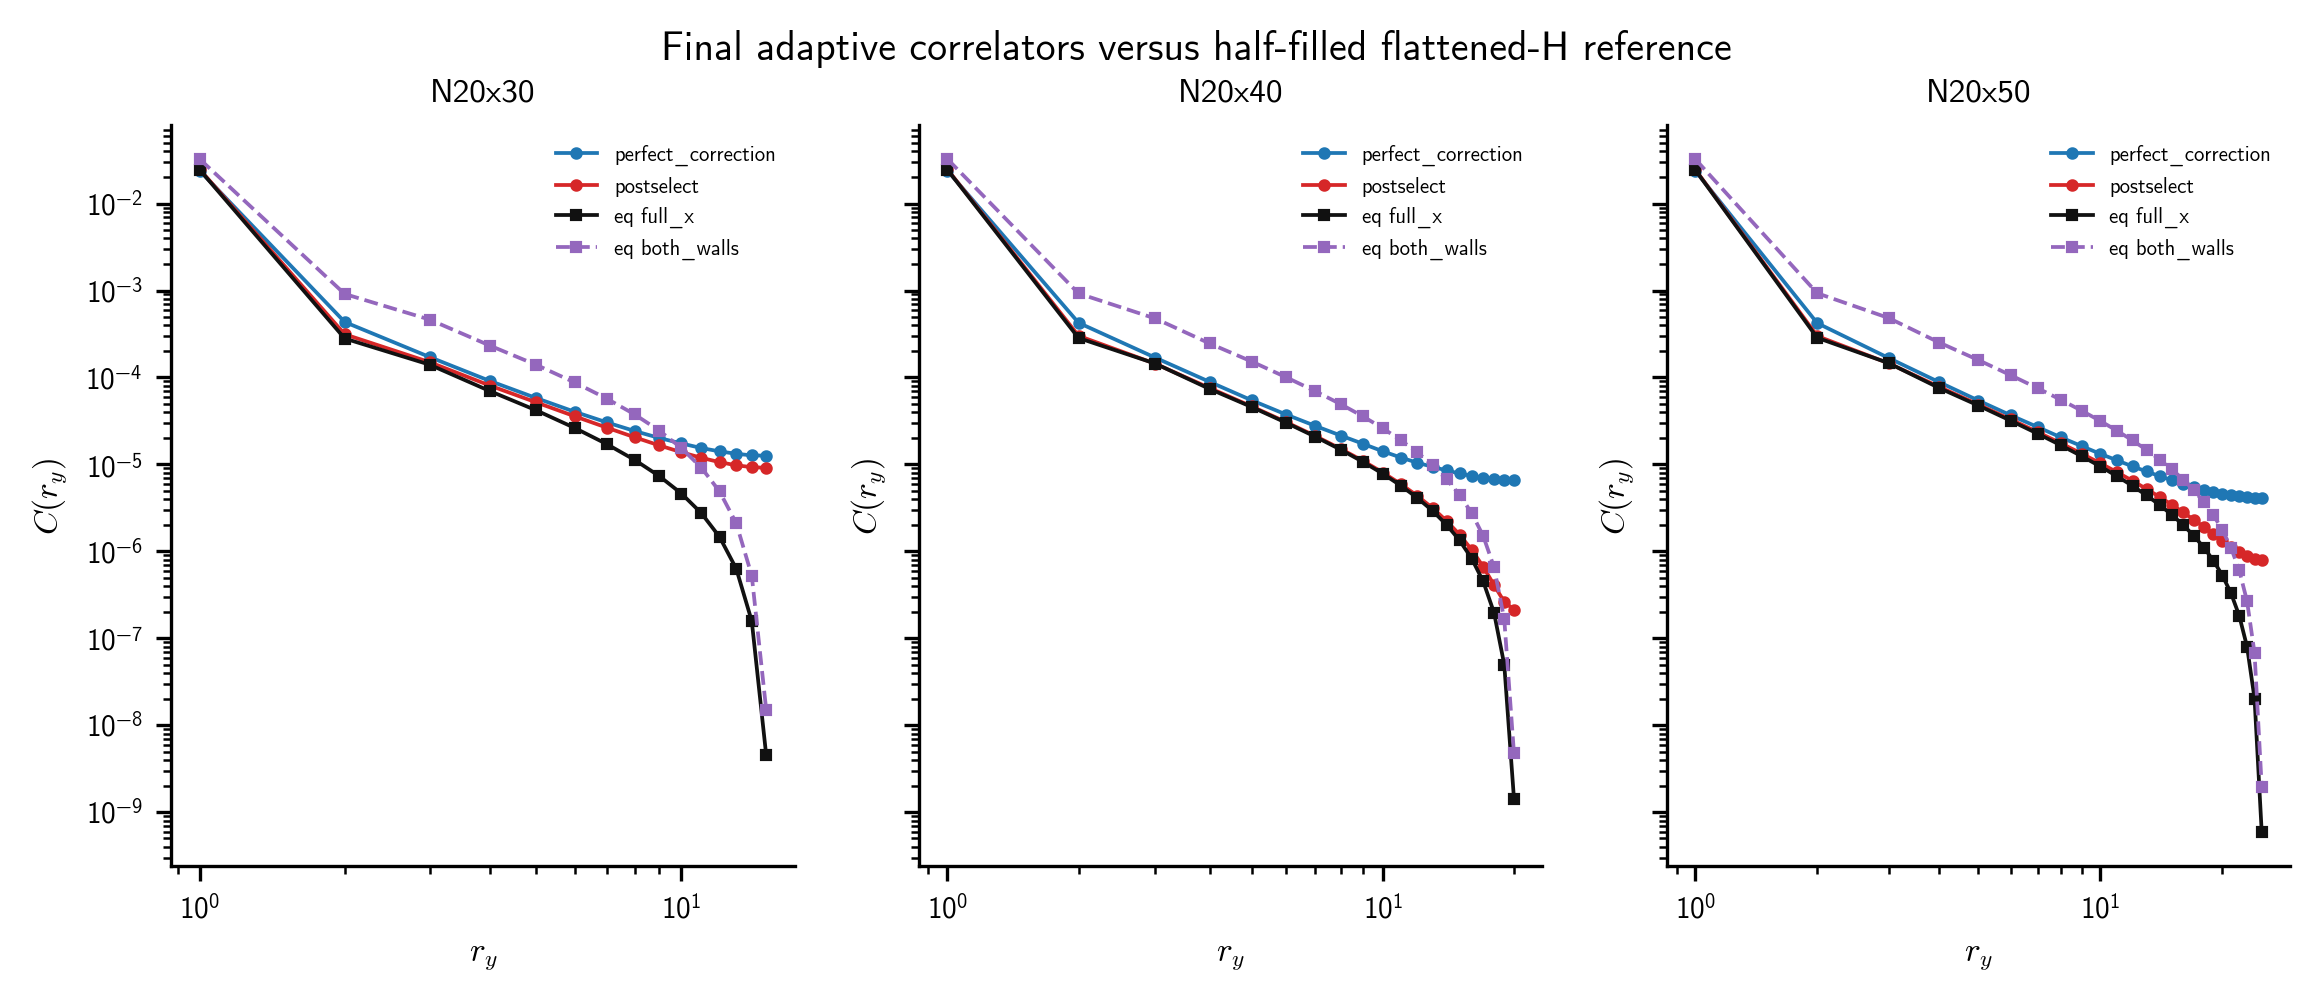

In [14]:
# Plot controls
SAVE_FIG = True
FIG_STEM = 'equilibrium_vs_dynamics_correlator_curves'
TITLE = 'Final adaptive correlators versus half-filled flattened-H reference'
Y_SCALE = 'log'
X_SCALE = 'log'
LEGEND_LOC = 'best'
COLORS = {
    'perfect_correction': '#1f77b4',
    'postselect': '#d62728',
    'equilibrium_full_x': '#111111',
    'equilibrium_both_walls': '#9467bd',
}

fig, axes = plt.subplots(1, len(N20_NY_VALUES), figsize=(2.7 * WIDTH, 0.95 * WIDTH), sharey=True)
if len(N20_NY_VALUES) == 1:
    axes = [axes]
for ax, ny in zip(axes, N20_NY_VALUES):
    for rec in [r for r in n20_records if r['Ny'] == ny]:
        final_corr = rec['corr'][:, -1, :].mean(axis=0)
        ry = rec['ry_values']
        mask = ry >= 1
        ax.plot(ry[mask], final_corr[mask], marker='o', markersize=2.0, linewidth=0.9,
                color=COLORS[rec['protocol']], label=rec['protocol'])
    for window, style_key, linestyle in [('full_x', 'equilibrium_full_x', '-'), ('both_walls', 'equilibrium_both_walls', '--')]:
        panel = equilibrium_curves[(equilibrium_curves['Ny'] == ny) & (equilibrium_curves['x_window'] == window)].sort_values('ry')
        panel = panel[panel['ry'] >= 1]
        ax.plot(panel['ry'], panel['square_correlator'], linestyle=linestyle, marker='s', markersize=2.0,
                linewidth=0.9, color=COLORS[style_key], label=f'eq {window}')
    ax.set_xscale(X_SCALE)
    ax.set_yscale(Y_SCALE)
    ax.set_title(f'N20x{ny}')
    ax.set_xlabel(r'$r_y$')
    ax.set_ylabel(r'$C(r_y)$')
    ax.legend(loc=LEGEND_LOC, frameon=False, fontsize=5)
fig.suptitle(TITLE)
save_figure(fig, FIG_STEM, save=SAVE_FIG)
plt.show()


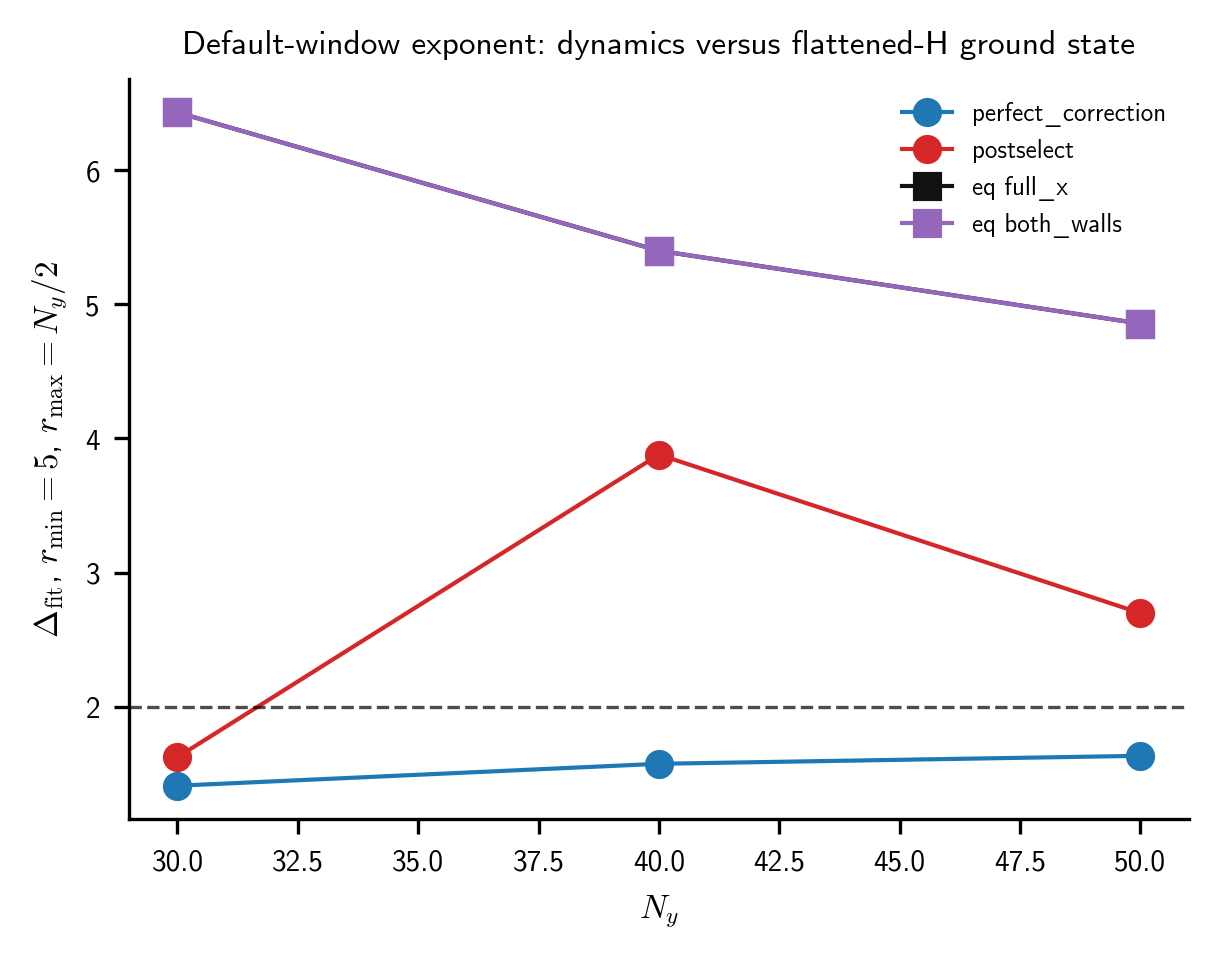

### Default-window comparison

,source,protocol,Ny,x_window,exponent_mean,exponent_std,r2_mean,n
0,N20_streaming_xavg,perfect_correction,30,full_x_streamed,1.411125,0.142797,0.962269,100
1,N20_streaming_xavg,postselect,30,full_x_streamed,1.623926,NaN,0.980325,1
2,equilibrium_flattened_half_fill,flattened_ground_state,30,both_walls,6.430597,NaN,0.752224,1
3,equilibrium_flattened_half_fill,flattened_ground_state,30,full_x,6.430628,NaN,0.752227,1
4,equilibrium_flattened_half_fill,flattened_ground_state,30,left_wall_window,6.430597,NaN,0.752224,1
5,equilibrium_flattened_half_fill,flattened_ground_state,30,nonwall_control,10.352678,NaN,0.913340,1
6,equilibrium_flattened_half_fill,flattened_ground_state,30,right_wall_window,6.430597,NaN,0.752224,1
7,equilibrium_flattened_half_fill,flattened_ground_state,30,topological_bulk,10.352678,NaN,0.913340,1
8,N20_streaming_xavg,perfect_correction,40,full_x_streamed,1.574658,0.254578,0.971724,100
9,N20_streaming_xavg,postselect,40,full_x_streamed,3.879581,NaN,0.948281,1


### Selected-window comparison

,source,protocol,Ny,x_window,r_min,r_max_label,exponent_mean,r2_mean,n
0,N20_streaming_xavg,perfect_correction,30,full_x_streamed,2,Ny//4,2.129518,0.996696,100
1,N20_streaming_xavg,postselect,30,full_x_streamed,2,Ny//4,1.992179,0.999374,1
2,equilibrium_flattened_half_fill,flattened_ground_state,30,both_walls,2,Ny//4,2.225998,0.992408,1
3,equilibrium_flattened_half_fill,flattened_ground_state,30,full_x,2,Ny//4,2.245902,0.993165,1
4,N20_streaming_xavg,perfect_correction,30,full_x_streamed,3,Ny//3,1.911971,0.992544,100
5,N20_streaming_xavg,postselect,30,full_x_streamed,3,Ny//3,1.981898,0.999126,1
6,equilibrium_flattened_half_fill,flattened_ground_state,30,both_walls,3,Ny//3,2.761110,0.989230,1
7,equilibrium_flattened_half_fill,flattened_ground_state,30,full_x,3,Ny//3,2.766961,0.989538,1
8,N20_streaming_xavg,perfect_correction,30,full_x_streamed,3,Ny//4,2.049906,0.996418,100
9,N20_streaming_xavg,postselect,30,full_x_streamed,3,Ny//4,2.043388,0.999631,1


In [15]:
# Plot controls
SAVE_TABLE = True
SAVE_FIG = True
FIG_STEM = 'equilibrium_vs_dynamics_default_exponent'
TITLE = r'Default-window exponent: dynamics versus flattened-H ground state'
Y_LABEL = r'$\Delta_{\rm fit}$, $r_{\min}=5$, $r_{\max}=N_y/2$'
LEGEND_LOC = 'best'

# Direct default-window comparison table.
dyn_default = final_n20[(final_n20['r_min'] == 5) & (final_n20['r_max_label'] == 'Ny//2')]
dyn_default_summary = dyn_default.groupby(['protocol', 'Ny'], as_index=False).agg(
    exponent_mean=('correlator_exponent', 'mean'),
    exponent_std=('correlator_exponent', 'std'),
    r2_mean=('correlator_loglog_r2', 'mean'),
    n=('correlator_exponent', 'size'),
)
dyn_default_summary['source'] = 'N20_streaming_xavg'
dyn_default_summary['x_window'] = 'full_x_streamed'

eq_default = equilibrium_fit_sweep[(equilibrium_fit_sweep['r_min'] == 5) & (equilibrium_fit_sweep['r_max_label'] == 'Ny//2')]
eq_default_summary = eq_default.groupby(['protocol', 'Ny', 'x_window'], as_index=False).agg(
    exponent_mean=('correlator_exponent', 'mean'),
    exponent_std=('correlator_exponent', 'std'),
    r2_mean=('correlator_loglog_r2', 'mean'),
    n=('correlator_exponent', 'size'),
)
eq_default_summary['source'] = 'equilibrium_flattened_half_fill'

default_comparison = pd.concat([
    dyn_default_summary[['source', 'protocol', 'Ny', 'x_window', 'exponent_mean', 'exponent_std', 'r2_mean', 'n']],
    eq_default_summary[['source', 'protocol', 'Ny', 'x_window', 'exponent_mean', 'exponent_std', 'r2_mean', 'n']],
], ignore_index=True)
default_comparison_path = TABLE_DIR / 'equilibrium_vs_dynamics_default_exponents.csv'
if SAVE_TABLE:
    save_dataframe(default_comparison, default_comparison_path)

fig, ax = plt.subplots(figsize=(1.35 * WIDTH, 0.95 * WIDTH))
series = [
    ('perfect_correction', dyn_default_summary[dyn_default_summary['protocol'] == 'perfect_correction'], '#1f77b4', 'o'),
    ('postselect', dyn_default_summary[dyn_default_summary['protocol'] == 'postselect'], '#d62728', 'o'),
    ('eq full_x', eq_default_summary[eq_default_summary['x_window'] == 'full_x'], '#111111', 's'),
    ('eq both_walls', eq_default_summary[eq_default_summary['x_window'] == 'both_walls'], '#9467bd', 's'),
]
for label, panel, color, marker in series:
    panel = panel.sort_values('Ny')
    ax.plot(panel['Ny'], panel['exponent_mean'], marker=marker, color=color, linewidth=1.0, label=label)
ax.axhline(TARGET_EXPONENT, color='k', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_xlabel(r'$N_y$')
ax.set_ylabel(Y_LABEL)
ax.set_title(TITLE)
ax.legend(loc=LEGEND_LOC, frameon=False, fontsize=6)
save_figure(fig, FIG_STEM, save=SAVE_FIG)
plt.show()


# A compact table for the windows that diagnose the crossover most cleanly.
SELECTED_COMPARE_WINDOWS = [(2, 'Ny//4'), (3, 'Ny//4'), (3, 'Ny//3'), (5, 'Ny//2')]
selected_rows = []
for r_min, r_max_label in SELECTED_COMPARE_WINDOWS:
    for ny in N20_NY_VALUES:
        for protocol in N20_PROTOCOLS:
            panel = final_n20[
                (final_n20['Ny'] == ny)
                & (final_n20['protocol'] == protocol)
                & (final_n20['r_min'] == r_min)
                & (final_n20['r_max_label'] == r_max_label)
            ]
            selected_rows.append({
                'source': 'N20_streaming_xavg',
                'protocol': protocol,
                'Ny': int(ny),
                'x_window': 'full_x_streamed',
                'r_min': int(r_min),
                'r_max_label': r_max_label,
                'exponent_mean': float(panel['correlator_exponent'].mean()),
                'r2_mean': float(panel['correlator_loglog_r2'].mean()),
                'n': int(len(panel)),
            })
        for x_window in ['full_x', 'both_walls']:
            panel = equilibrium_fit_sweep[
                (equilibrium_fit_sweep['Ny'] == ny)
                & (equilibrium_fit_sweep['x_window'] == x_window)
                & (equilibrium_fit_sweep['r_min'] == r_min)
                & (equilibrium_fit_sweep['r_max_label'] == r_max_label)
            ]
            selected_rows.append({
                'source': 'equilibrium_flattened_half_fill',
                'protocol': 'flattened_ground_state',
                'Ny': int(ny),
                'x_window': x_window,
                'r_min': int(r_min),
                'r_max_label': r_max_label,
                'exponent_mean': float(panel['correlator_exponent'].mean()),
                'r2_mean': float(panel['correlator_loglog_r2'].mean()),
                'n': int(len(panel)),
            })
selected_window_comparison = pd.DataFrame(selected_rows)
selected_window_comparison_path = TABLE_DIR / 'equilibrium_vs_dynamics_selected_window_exponents.csv'
if SAVE_TABLE:
    save_dataframe(selected_window_comparison, selected_window_comparison_path)

display(Markdown('### Default-window comparison'))
display(default_comparison.sort_values(['Ny', 'source', 'x_window', 'protocol']).reset_index(drop=True))

display(Markdown('### Selected-window comparison'))
display(selected_window_comparison.sort_values(['Ny', 'r_min', 'r_max_label', 'source', 'x_window', 'protocol']).reset_index(drop=True))


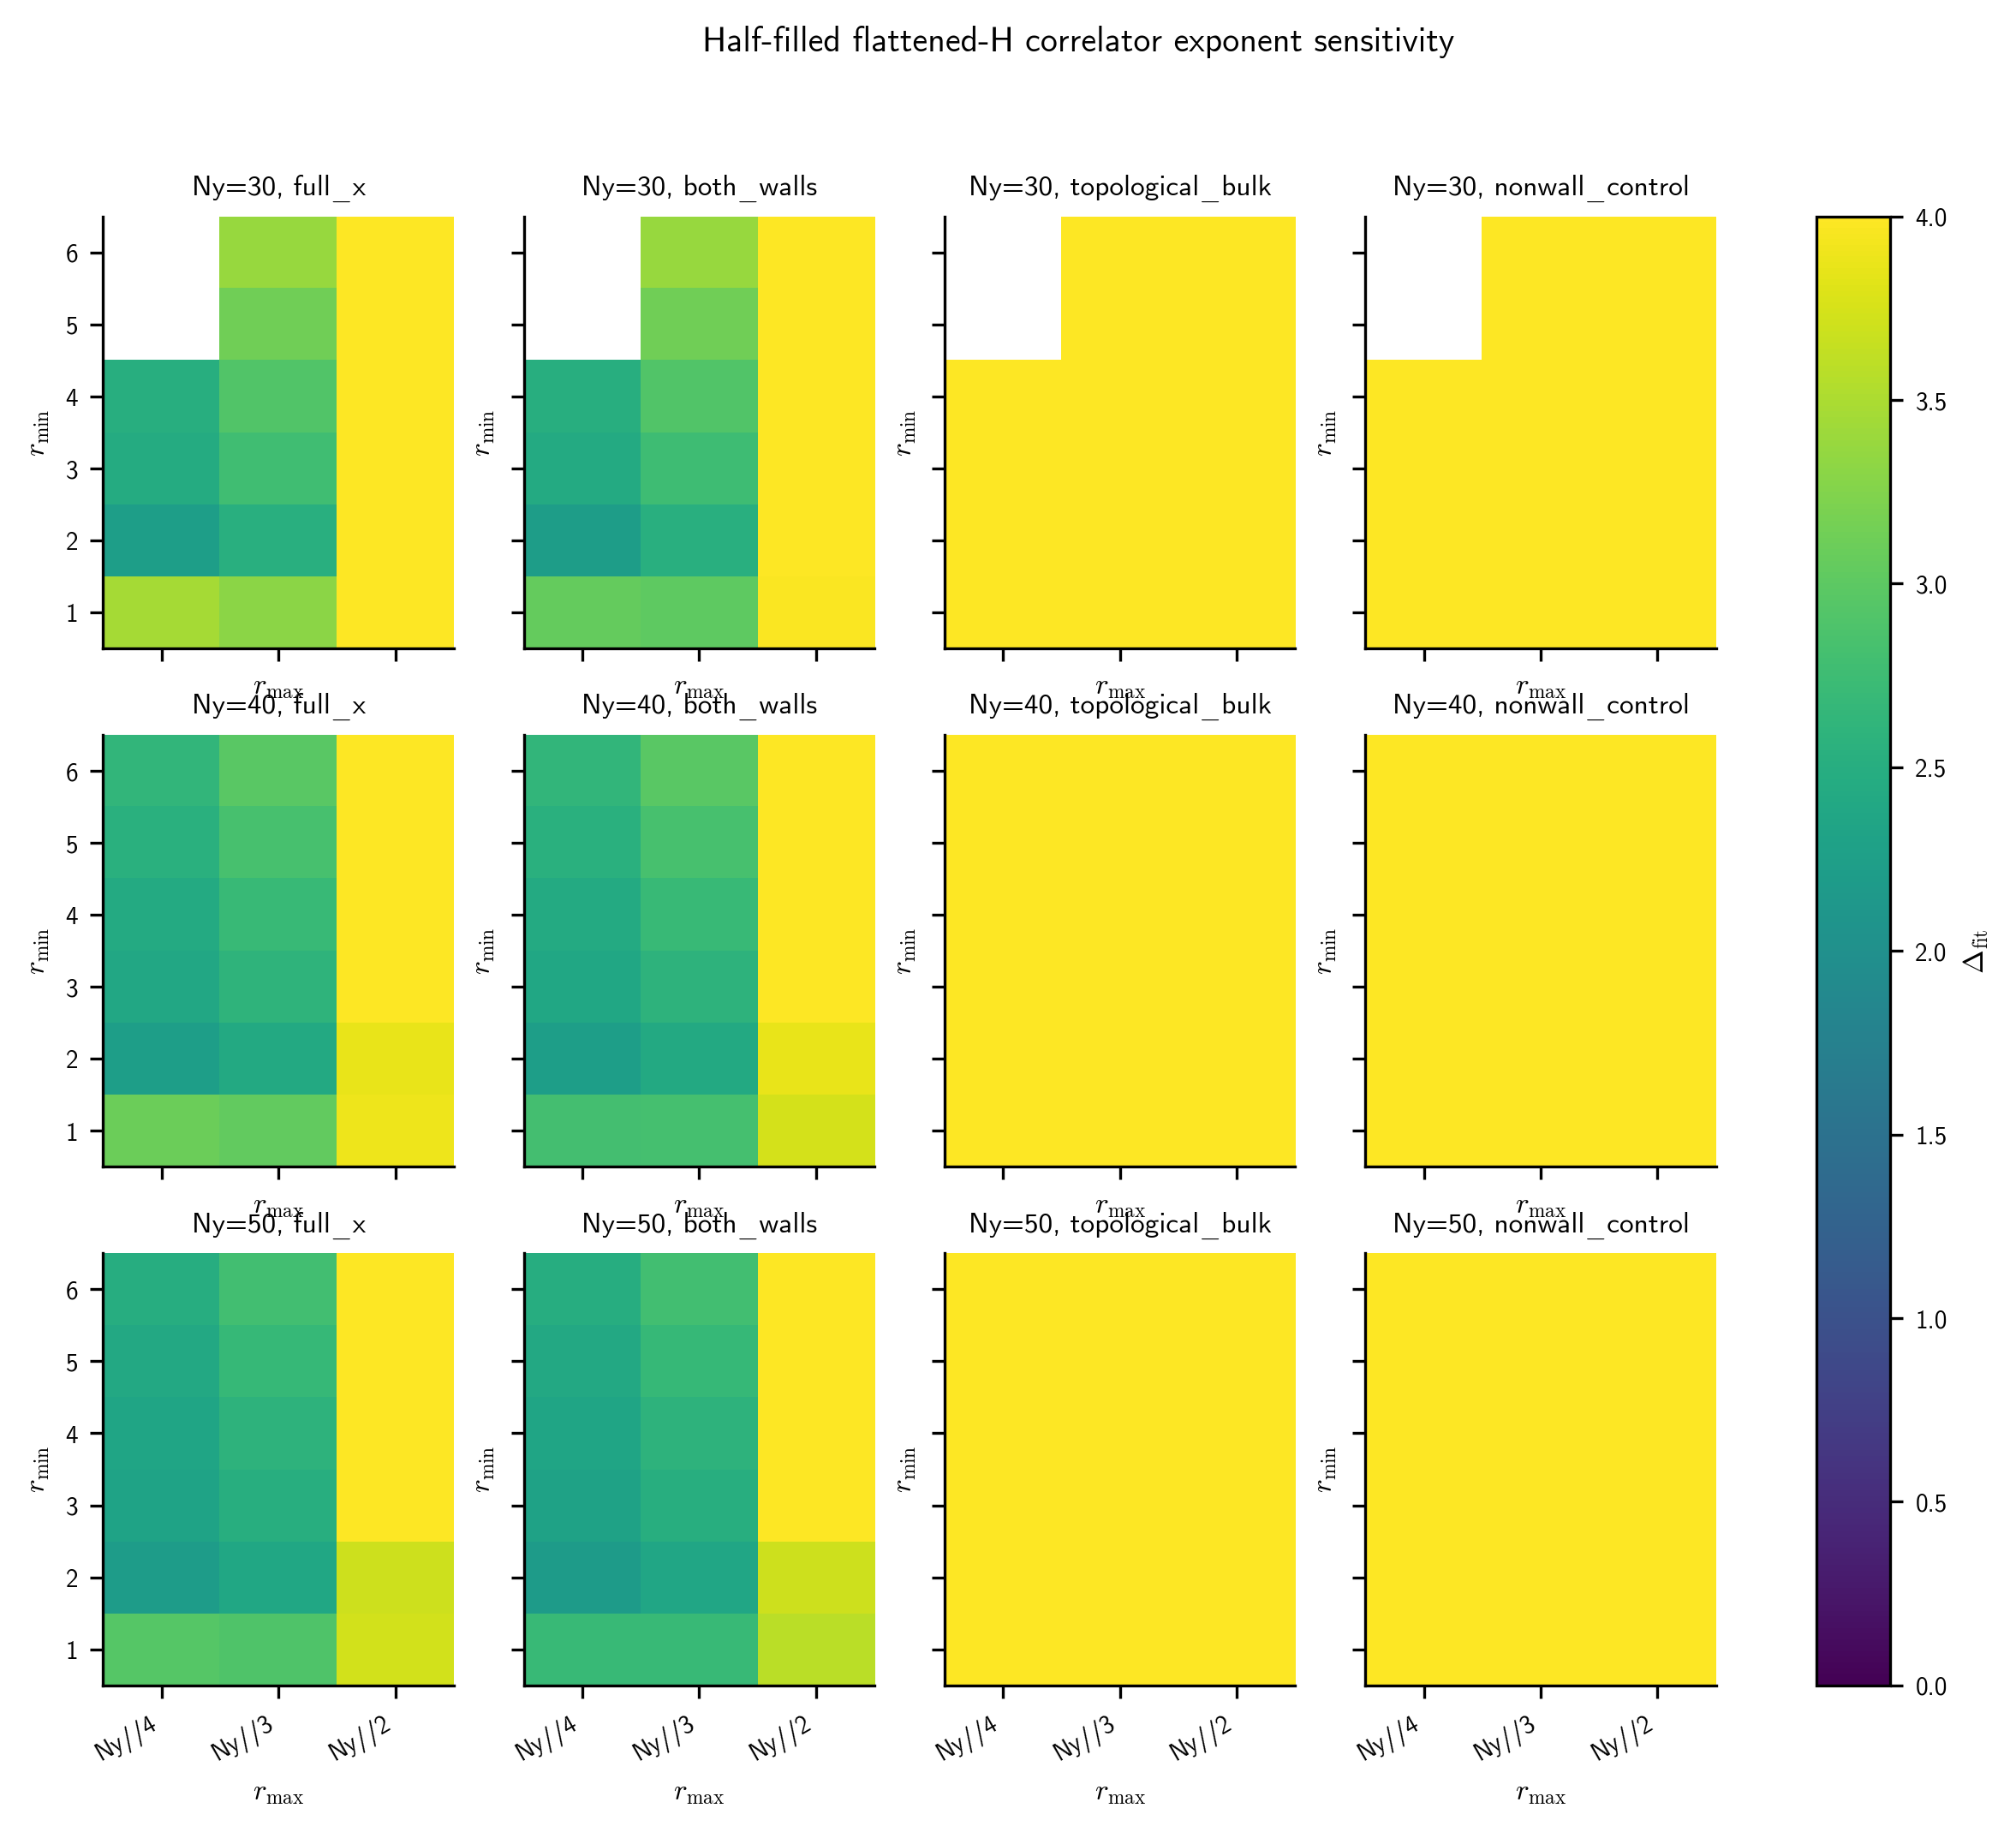

In [16]:
# Plot controls
SAVE_FIG = True
FIG_STEM = 'equilibrium_flattened_fit_heatmap'
TITLE = 'Half-filled flattened-H correlator exponent sensitivity'
CMAP = 'viridis'
VMIN = 0.0
VMAX = 4.0
WINDOWS_TO_SHOW = ['full_x', 'both_walls', 'topological_bulk', 'nonwall_control']

summary_eq = equilibrium_fit_sweep.groupby(['Ny', 'x_window', 'r_min', 'r_max_label'], as_index=False).agg(
    exponent_mean=('correlator_exponent', 'mean'),
    r2_mean=('correlator_loglog_r2', 'mean'),
)
rmax_order = ['Ny//4', 'Ny//3', 'Ny//2']
fig, axes = plt.subplots(len(N20_NY_VALUES), len(WINDOWS_TO_SHOW), figsize=(3.0 * WIDTH, 2.2 * WIDTH), sharex=True, sharey=True)
for i, ny in enumerate(N20_NY_VALUES):
    for j, window in enumerate(WINDOWS_TO_SHOW):
        ax = axes[i, j]
        panel = summary_eq[(summary_eq['Ny'] == ny) & (summary_eq['x_window'] == window)]
        pivot = panel.pivot(index='r_min', columns='r_max_label', values='exponent_mean').reindex(index=R_MIN_VALUES, columns=rmax_order)
        im = ax.imshow(pivot.to_numpy(), origin='lower', aspect='auto', cmap=CMAP, vmin=VMIN, vmax=VMAX)
        ax.set_title(f'Ny={ny}, {window}')
        ax.set_xticks(range(len(rmax_order)), rmax_order, rotation=30, ha='right')
        ax.set_yticks(range(len(R_MIN_VALUES)), R_MIN_VALUES)
        ax.set_xlabel(r'$r_{\max}$')
        ax.set_ylabel(r'$r_{\min}$')
fig.colorbar(im, ax=axes.ravel().tolist(), label=r'$\Delta_{\rm fit}$')
fig.suptitle(TITLE)
save_figure(fig, FIG_STEM, save=SAVE_FIG)
plt.show()


## Final Decision Table


In [17]:
def verdict_bool(condition: bool) -> str:
    return 'supported' if bool(condition) else 'not supported'

# Criteria are diagnostic, not claims of universality.
default_final = final_n20[(final_n20['r_min'] == 5) & (final_n20['r_max_label'] == 'Ny//2')]
default_summary = default_final.groupby(['protocol', 'Ny'], as_index=False).agg(
    exponent_mean=('correlator_exponent', 'mean'),
    exponent_std=('correlator_exponent', 'std'),
    r2_mean=('correlator_loglog_r2', 'mean'),
)
window_spread_big = float(n20_spread_summary['mean_spread'].max()) > 0.5
postselect_unstable = float(default_summary[default_summary['protocol'] == 'postselect']['exponent_mean'].max() - default_summary[default_summary['protocol'] == 'postselect']['exponent_mean'].min()) > 1.0
wall_bulk_spread = n16_spread_summary.groupby('Ny')['mean_spread'].max().max() > 0.5

# Compare full_x to wall-only at default window in N16 cycle 50.
n16_default = final_n16[(final_n16['r_min'] == 5) & (final_n16['r_max_label'] == 'Ny//2') & (final_n16['nshell'] == 1)]
n16_default_stats = n16_default.groupby(['Ny', 'x_window'], as_index=False).agg(exponent_mean=('correlator_exponent', 'mean'))
wall_vs_full_rows = []
for ny in N16_NY_VALUES:
    panel = n16_default_stats[n16_default_stats['Ny'] == ny].set_index('x_window')['exponent_mean']
    if 'full_x' in panel and 'both_walls' in panel:
        wall_vs_full_rows.append(abs(float(panel['both_walls'] - panel['full_x'])))
wall_full_difference = max(wall_vs_full_rows) if wall_vs_full_rows else np.nan

# Equilibrium reference diagnostics.
eq_default = equilibrium_fit_sweep[(equilibrium_fit_sweep['r_min'] == 5) & (equilibrium_fit_sweep['r_max_label'] == 'Ny//2')]
eq_both_default = eq_default[eq_default['x_window'] == 'both_walls']
eq_both_default_max_error = float(np.nanmax(np.abs(eq_both_default['correlator_exponent'] - TARGET_EXPONENT)))
eq_full_default = eq_default[eq_default['x_window'] == 'full_x']
eq_full_default_max_error = float(np.nanmax(np.abs(eq_full_default['correlator_exponent'] - TARGET_EXPONENT)))

eq_window_spread = equilibrium_fit_sweep.groupby(['Ny', 'x_window'], as_index=False).agg(
    exponent_min=('correlator_exponent', 'min'),
    exponent_max=('correlator_exponent', 'max'),
)
eq_window_spread['spread'] = eq_window_spread['exponent_max'] - eq_window_spread['exponent_min']
eq_wall_window_spread_max = float(eq_window_spread[eq_window_spread['x_window'] == 'both_walls']['spread'].max())

pc_default = default_summary[default_summary['protocol'] == 'perfect_correction'].set_index('Ny')['exponent_mean']
eq_default_both_by_ny = eq_both_default.set_index('Ny')['correlator_exponent']
common_ny = sorted(set(pc_default.index).intersection(eq_default_both_by_ny.index))
pc_below_eq_rows = [float(eq_default_both_by_ny.loc[ny] - pc_default.loc[ny]) for ny in common_ny]
pc_below_eq_min_gap = float(np.nanmin(pc_below_eq_rows)) if pc_below_eq_rows else np.nan

criteria_rows = [
    {
        'hypothesis': 'N20 exponent instability is fit-window sensitive',
        'verdict': verdict_bool(window_spread_big),
        'criterion': 'maximum final-cycle mean window spread over protocols/geometries exceeds 0.5',
        'diagnostic_value': float(n20_spread_summary['mean_spread'].max()),
        'primary_table': 'tables/n20_xavg_window_sweep.csv',
    },
    {
        'hypothesis': 'postselected x-averaged correlator is not uniformly cleaner',
        'verdict': verdict_bool(postselect_unstable),
        'criterion': 'postselect default final exponent varies by more than 1 across Ny',
        'diagnostic_value': float(default_summary[default_summary['protocol'] == 'postselect']['exponent_mean'].max() - default_summary[default_summary['protocol'] == 'postselect']['exponent_mean'].min()),
        'primary_table': 'tables/n20_xavg_window_sweep.csv',
    },
    {
        'hypothesis': 'wall/bulk mixing affects apparent exponent',
        'verdict': verdict_bool(bool(wall_full_difference > 0.25)),
        'criterion': 'N16 default-window both-wall exponent differs from full-x by more than 0.25 for some Ny',
        'diagnostic_value': float(wall_full_difference),
        'primary_table': 'tables/n16_wall_localized_fit_sweep.csv',
    },
    {
        'hypothesis': 'N16 wall-localized fits are still window-sensitive',
        'verdict': verdict_bool(bool(wall_bulk_spread)),
        'criterion': 'maximum N16 cycle-50 mean window spread exceeds 0.5',
        'diagnostic_value': float(n16_spread_summary['mean_spread'].max()),
        'primary_table': 'tables/n16_wall_localized_fit_sweep.csv',
    },
    {
        'hypothesis': 'half-filled flattened-H both-wall correlator realizes the expected exponent near 2',
        'verdict': verdict_bool(eq_both_default_max_error < 0.1),
        'criterion': 'default-window both-wall exponent differs from 2 by less than 0.1 for every Ny',
        'diagnostic_value': eq_both_default_max_error,
        'primary_table': 'tables/equilibrium_flattened_half_fill_fit_sweep.csv',
    },
    {
        'hypothesis': 'adaptive perfect-correction correlator is below the flattened-H exponent benchmark',
        'verdict': verdict_bool(pc_below_eq_min_gap > 0.25),
        'criterion': 'equilibrium both-wall default exponent exceeds perfect-correction default exponent by more than 0.25 for every shared Ny',
        'diagnostic_value': pc_below_eq_min_gap,
        'primary_table': 'tables/equilibrium_vs_dynamics_default_exponents.csv',
    },
]
decision = pd.DataFrame(criteria_rows)
decision_path = TABLE_DIR / 'correlator_diagnostic_decision_table.csv'
save_dataframe(decision, decision_path)

summary_paths = {
    'n20_window_sweep': str(n20_window_sweep_path),
    'n16_curves': str(n16_curves_path),
    'n16_fit_sweep': str(n16_fit_path),
    'equilibrium_curves': str(equilibrium_curves_path),
    'equilibrium_fit_sweep': str(equilibrium_fit_path),
    'equilibrium_entropy_profile': str(equilibrium_entropy_path),
    'equilibrium_state_summary': str(equilibrium_state_summary_path),
    'equilibrium_finite_size_entropy_reference': str(flat_entropy_reference_path) if flat_entropy_reference_path is not None else None,
    'equilibrium_vs_dynamics_default_exponents': str(default_comparison_path),
    'equilibrium_vs_dynamics_selected_window_exponents': str(selected_window_comparison_path),
    'decision_table': str(decision_path),
    'figure_dir': str(FIG_DIR),
    'domain_wall_convention': 'current source convention: half=Nx//2, w=Nx//4, DW_loc=[half-w, half+w]',
    'equilibrium_reference': 'half-filled ground state of OW-projector flattened Hamiltonian, alpha_2=30, dw_truncation=True, trial_orbital=X, nshell=1',
    'source_data_only_for_dynamics': True,
    'no_markov_dynamics_run': True,
}
with (OUTPUT_ROOT / 'analysis_manifest.json').open('w', encoding='utf-8') as fh:
    json.dump(summary_paths, fh, indent=2, sort_keys=True)

display(Markdown('### Decision table'))
display(decision)
print(json.dumps(summary_paths, indent=2))


### Decision table

,hypothesis,verdict,criterion,diagnostic_value,primary_table
0,N20 exponent instability is fit-window sensitive,supported,maximum final-cycle mean window spread over pr...,1.953628,tables/n20_xavg_window_sweep.csv
1,postselected x-averaged correlator is not unif...,supported,postselect default final exponent varies by mo...,2.255655,tables/n20_xavg_window_sweep.csv
2,wall/bulk mixing affects apparent exponent,not supported,N16 default-window both-wall exponent differs ...,0.004453,tables/n16_wall_localized_fit_sweep.csv
3,N16 wall-localized fits are still window-sensi...,supported,maximum N16 cycle-50 mean window spread exceed...,4.654907,tables/n16_wall_localized_fit_sweep.csv
4,half-filled flattened-H both-wall correlator r...,not supported,default-window both-wall exponent differs from...,4.430597,tables/equilibrium_flattened_half_fill_fit_swe...
5,adaptive perfect-correction correlator is belo...,supported,equilibrium both-wall default exponent exceeds...,3.222302,tables/equilibrium_vs_dynamics_default_exponen...


{
  "n20_window_sweep": "/home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/correlator_scaling_diagnostics/tables/n20_xavg_window_sweep.csv",
  "n16_curves": "/home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/correlator_scaling_diagnostics/tables/n16_wall_localized_correlator_curves.csv",
  "n16_fit_sweep": "/home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/correlator_scaling_diagnostics/tables/n16_wall_localized_fit_sweep.csv",
  "equilibrium_curves": "/home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/correlator_scaling_diagnostics/tables/equilibrium_flattened_half_fill_correlator_curves.csv",
  "equilibrium_fit_sweep": "/home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/correlator_scaling_diagnostics/tables/equilibrium_flattened_half_fill_fit_sweep.csv",
  "equilibrium_entro